# ☀️ Solar Energy Production
🇫🇷 **France - 2020 to 2026**

This notebook explores the relationship between meteorological conditions and solar energy production in France, using data from **RTE** (electricity transport network) and **Meteo-France** (weather data).

## 📁 Project Structure
```
📁 Project
├── 🗒️ solar_production
├── 🗒️ RTE_concat
└── 📁 data
    ├── 📁 coordinates
    │   ├── 📄 departements-20180101.cpg
    │   ├── 📄 departements-20180101.dbf
    │   ├── 📄 departements-20180101.prj
    │   ├── 📄 departements-20180101.shp
    │   ├── 📄 departements-20180101.shx
    │   ├── 📄 departements-descriptif.txt
    │   └── 📄 LICENCE.txt
    ├── 📁 Meteo-France
    │   ├── 📄 QUOT_SIM2_2010-2019.csv
    │   └── 📄 QUOT_SIM2_previous-2020-202605.csv
    ├── 📁 RTE
    │   ├── 📁 Regions
    │   │   ├── 📄 eCO2mix_RTE_Auvergne-Rhône-Alpes_Annuel-Definitif_2013.xls
    │   │   ├── 📄 eCO2mix_RTE_Auvergne-Rhône-Alpes_Annuel-Definitif_2014.xls
    │   │   └── 📄 ...
    │   ├── 📄 rte_regions_2013.csv
    │   ├── 📄 rte_regions_2014.csv
    │   ├── 📄 rte_regions_2015.csv
    │   ├── 📄 rte_regions_2016.csv
    │   ├── 📄 rte_regions_2017.csv
    │   ├── 📄 rte_regions_2018.csv
    │   ├── 📄 rte_regions_2019.csv
    │   ├── 📄 rte_regions_2020.csv
    │   ├── 📄 rte_regions_2021.csv
    │   ├── 📄 rte_regions_2022.csv
    │   ├── 📄 rte_regions_2023.csv
    │   ├── 📄 rte_regions_2024.csv
    │   └── 📄 rte_regions_en_cours.csv
    └── 📁 solar_installations
        └── 📄 statistiques_sdes_2026_t1_tb_dpt_installations_solaires_photovoltaiques_v2.xlsx
```

# ⬇️ 1. Modules imports & loading data 

### &nbsp;&nbsp;&nbsp; A. Modules

In [163]:
# Imports for data
import numpy as np
import pandas as pd

# Imports for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Imports for machine learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor

# Geoloc converter
import geopandas as gpd
from pyproj import Transformer

# Other
import scipy.stats as stats
import warnings
import requests
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import pacf, acf

warnings.filterwarnings("ignore")

### &nbsp;&nbsp;&nbsp; B. Files and settings

In [164]:
# RTE datasource: 
# https://www.rte-france.com/donnees-publications/eco2mix-donnees-temps-reel/telecharger-indicateurs
# The files used are the aggregation per year of the regions datasets
PATH_RTE = 'data/RTE/' # Change this value to link to the RTE files

# Meteo-France datasource: 
# https://www.data.gouv.fr/datasets/donnees-changement-climatique-sim-quotidienne
PATH_MF = 'data/Meteo-France/' # Change this value to link to the MF files
mf_files_name = ['QUOT_SIM2_previous-2020-202605.csv']

# Solar pannel installation over time:
# https://www.statistiques.developpement-durable.gouv.fr/tableau-de-bord-solaire-photovoltaique-premier-trimestre-2026
PATH_SOLAR_INSTALL = 'data/solar_installations/' # Change this value to link to the MF files
solar_install = 'statistiques_sdes_2026_t1_tb_dpt_installations_solaires_photovoltaiques_v2.xlsx'

# Coordinates conversion to départements and régions:
# https://www.data.gouv.fr/datasets/contours-des-departements-francais-issus-d-openstreetmap
COORDINATES = 'data/coordinates/' # Change this value to link to the MF files


# Setting up date range so both datasources match
date_min = '2020-01-01' # Lower bound included
date_max = '2026-02-01' # Upper bound NOT included

# Setting up region dict so all our data are consistent and geo-compatible
region_dict = {
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # Solar installations + RTE
    "Bourgogne-Franche-Comté"       : "Bourgogne-Franche-Comté", # Solar installations + RTE
    "Bretagne"                      : "Bretagne", # Solar installations + RTE
    "Centre-Val de Loire"           : "Centre-Val de Loire", # Solar installations
    "Centre-Val-de-Loire"           : "Centre-Val de Loire", # RTE  
    "Grand Est"                     : "Grand Est", # Solar installations
    "Grand-Est"                     : "Grand Est", # RTE  
    "Hauts-de-France"               : "Hauts-de-France", # Solar installations + RTE
    "Normandie"                     : "Normandie", # Solar installations + RTE
    "Nouvelle-Aquitaine"            : "Nouvelle-Aquitaine", # Solar installations + RTE
    "Occitanie"                     : "Occitanie", # Solar installations + RTE
    "Pays de la Loire"              : "Pays de la Loire", # Solar installations
    "Pays-de-la-Loire"              : "Pays de la Loire", # RTE 
    "Provence-Alpes-Côte d'Azur"    : "Provence-Alpes-Côte d'Azur", # Solar installations
    "PACA"                          : "Provence-Alpes-Côte d'Azur", # RTE 
    "Île-de-France"                 : "Île-de-France", # Solar installations
    "Ile-de-France"                 : "Île-de-France", # RTE 
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # Solar installations
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # RTE
    "Corse"                         : "Corse",
}

### &nbsp;&nbsp;&nbsp; C. Loading RTE data

In [165]:
# Loading dataset
# The files are the aggregation per year and by region of the datasets provided by RTE
# The conversion can be done with RTE_concat notebook
df_list = []
for year in range(2020, 2025):
    file = f"{PATH_RTE}rte_regions_{year}.csv"
    # index_col=False to avoid column name offset
    # usecols to keep only the solar relative data
    # parse_dates to get proper date format while loading
    df = pd.read_csv(file, sep=",", encoding="utf-8", index_col=False, usecols=['Date', 'Solaire', 'region'], parse_dates=['Date'])
    df_list.append(df)

# Adding the current not consolidated data > 2024
current = f"{PATH_RTE}rte_regions_en_cours.csv"
df = pd.read_csv(current, sep=",", encoding="utf-8", index_col=False, usecols=['Date', 'Solaire', 'region'], parse_dates=['Date'])
df = df[df['Date'] <= date_max] # Keeping until the date_max we setted up earlier
df_list.append(df)

rte_df = pd.concat(df_list, ignore_index=True)
rte_df = rte_df.dropna(subset=['Solaire']) # Droping rows without measurements

# Converting regions' name
rte_df['region'] = rte_df['region'].map(region_dict)

print('RTE data successfully loaded !')

RTE data successfully loaded !


### &nbsp;&nbsp;&nbsp; D. Reshaping RTE data

In [166]:
# Converting to TWh: more readable and understandable than raw production
# Multipling by 0.5 because it's half an hour value to get TWh
# Divide by 1_000_000 to get TWh instead of MWh for readability
# Terrawatts hour = Megawatts × Hours / 1_000_000
rte_df['TWh'] = rte_df['Solaire'] * 0.5 / 1_000_000

# Grouping data by date
rte_df = rte_df.groupby(['Date','region'])[['Solaire', 'TWh']].sum().reset_index()
print('RTE data reshaped successfully !')

RTE data reshaped successfully !


### &nbsp;&nbsp;&nbsp; E. Loading solar installations data

In [167]:
# Load the data, there's 2 headers...
solar_install_df = pd.read_excel(f'{PATH_SOLAR_INSTALL}{solar_install}', header=[2, 3])

# Dropping unused values
solar_install_df = solar_install_df[
    solar_install_df.iloc[:, 0].notna() &                                   # Keep rows with region name
    solar_install_df.iloc[:, 2].isna() &                                    # Exclude overseas: only rows that are not na
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Total') &      # Remove Total rows
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Le parc') &    # Remove footnote 'Le parc...'
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('p :') &        # Remove footnote 'p :...'
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Source')       # Remove footnote 'Source...'
].iloc[:, [0] + list(range(3, len(solar_install_df.columns)))]              # Remove col 1 and 2 (départements str and id)


# Rename the region column
solar_install_df = solar_install_df.rename(columns={'Unnamed: 0_level_0': 'region'}, level=0)
solar_install_df = solar_install_df.rename(columns={'Unnamed: 0_level_1': 'region'}, level=1)


# Set region as index
solar_install_df = solar_install_df.set_index(('region', 'region'))
solar_install_df.index.name = 'region'


# Stack date level into rows
solar_install_df = (solar_install_df
                      .stack(level=0) # Brings the dates down as rows, leaving nombre and puissance as columns
                      .reset_index()
                      .rename(columns={'level_1': 'date'})
                     )


# Resample to daily, forward fill
solar_install_df = solar_install_df.set_index('date')

solar_install_daily = (solar_install_df
                    .drop(columns='region')          # Avoid duplicated region column
                    .groupby(solar_install_df['region'])
                    .resample('D')
                    .ffill()
                    .reset_index())

# Doing this after the forward fill to avoid start in the first day of the year
# Keep only the dates boundaries
solar_install_daily = solar_install_daily[(solar_install_daily['date'] >= date_min) & 
                                     (solar_install_daily['date'] < date_max)
                                     ]

# Converting regions' name
solar_install_daily['region'] = solar_install_daily['region'].map(region_dict)

print('Solar installations data successfully loaded !')

Solar installations data successfully loaded !


### &nbsp;&nbsp;&nbsp; F. Getting all geoloc combinaisons in our Météo-France data

In [168]:
# Loading data
df_list = []
for files in mf_files_name:
    file = f"{PATH_MF}{files}"
    # Reading the file by chunks to get a smooth data loading 
    # Keeping only X and Y coordinates
    for chunk in pd.read_csv(file, sep=';', index_col=False, chunksize=100_000, usecols=['LAMBX', 'LAMBY']):
        df_list.append(chunk)

geo_loc_df = pd.concat(df_list, ignore_index=True)

# Keeping all X and Y combinations into 1 dataframe to get the associated region
geo_loc_df.drop_duplicates(inplace=True)

print('Coordinates successfully loaded !')

Coordinates successfully loaded !


### &nbsp;&nbsp;&nbsp; G. Converting coordinates 

In [169]:
# Define the coordinate transformer
# Meteo-France uses Lambert II étendu (EPSG:27572)
# We convert to WGS84 (EPSG:4326) which is the standard GPS lat/lon system
transformer = Transformer.from_crs("EPSG:27572", "EPSG:4326", always_xy=True)

# Get unique grid points
# The MF dataset has 50M+ rows but only 9892 unique LAMBX/LAMBY combinations
# Working on unique coordinates is much faster than converting every row
coords = geo_loc_df[['LAMBX', 'LAMBY']].drop_duplicates()

# Convert Lambert coordinates to GPS lon/lat
# MF stores coordinates in decameters (units of 10m), so multiply by 100
# to get meters which is what the transformer expects
# always_xy=True ensures the order is always (longitude, latitude)
coords['lon'], coords['lat'] = transformer.transform(
    coords['LAMBX'] * 100,
    coords['LAMBY'] * 100
)

# Create a GeoDataFrame from the coordinates
# points_from_xy() creates Point objects from lon/lat columns
# crs="EPSG:4326" tells geopandas these are GPS coordinates
coords_gdf = gpd.GeoDataFrame(
    coords,
    geometry=gpd.points_from_xy(coords['lon'], coords['lat']),
    crs="EPSG:4326"
)

### &nbsp;&nbsp;&nbsp; H. Loading départements shapes and matching coordinates to départements

In [170]:
# Load département boundaries
# The shapefile contains polygon geometries of all French départements
# .to_crs("EPSG:4326") reprojects the shapefile to GPS coordinates
# so both GeoDataFrames use the same coordinate system for the join
departements = gpd.read_file('data/coordinates/departements-20180101.shp').to_crs("EPSG:4326")

# Spatial join: point in polygon
# For each point in coords_gdf, find which département polygon it falls inside
# how='left' keeps all points even if no département is found
# predicate='within' means: the point must be strictly inside the polygon
coords_with_dep = gpd.sjoin(coords_gdf, departements, how='left', predicate='within')

# Handle unmatched points
# Some points fall on borders or just outside polygons (coastal points, etc.)
# and get NaN for code_insee: split matched vs unmatched
matched   = coords_with_dep[coords_with_dep['code_insee'].notna()]
unmatched = coords_with_dep[coords_with_dep['code_insee'].isna()][['LAMBX', 'LAMBY', 'lon', 'lat', 'geometry']]

# For unmatched points, use nearest département instead of strict containment
# sjoin_nearest finds the closest polygon even if the point is outside it
unmatched_fixed = gpd.sjoin_nearest(unmatched, departements, how='left')

# Combine and verify
# Merge matched and nearest-fixed rows back together
coords_to_region = pd.concat([matched, unmatched_fixed], ignore_index=True)
coords_to_region.drop(columns=['geometry', 'index_right', 'nuts3', 'wikipedia', 'surf_km2', 'nom', 'lon', 'lat'], inplace=True)

### &nbsp;&nbsp;&nbsp; I. Converting départements to région to match RTE's data

In [171]:
# Converting départements to région to match RTE's data
dept_to_region = {
    # Auvergne-Rhône-Alpes
    '01': 'Auvergne-Rhône-Alpes', '03': 'Auvergne-Rhône-Alpes',
    '07': 'Auvergne-Rhône-Alpes', '15': 'Auvergne-Rhône-Alpes',
    '26': 'Auvergne-Rhône-Alpes', '38': 'Auvergne-Rhône-Alpes',
    '42': 'Auvergne-Rhône-Alpes', '43': 'Auvergne-Rhône-Alpes',
    '63': 'Auvergne-Rhône-Alpes', '69': 'Auvergne-Rhône-Alpes',
    '69D': 'Auvergne-Rhône-Alpes',  # Rhône hors métropole
    '69M': 'Auvergne-Rhône-Alpes',  # Métropole de Lyon
    '73': 'Auvergne-Rhône-Alpes', '74': 'Auvergne-Rhône-Alpes',

    # Bourgogne-Franche-Comté
    '21': 'Bourgogne-Franche-Comté', '25': 'Bourgogne-Franche-Comté',
    '39': 'Bourgogne-Franche-Comté', '58': 'Bourgogne-Franche-Comté',
    '70': 'Bourgogne-Franche-Comté', '71': 'Bourgogne-Franche-Comté',
    '89': 'Bourgogne-Franche-Comté', '90': 'Bourgogne-Franche-Comté',

    # Bretagne
    '22': 'Bretagne', '29': 'Bretagne', '35': 'Bretagne', '56': 'Bretagne',

    # Centre-Val de Loire
    '18': 'Centre-Val de Loire', '28': 'Centre-Val de Loire',
    '36': 'Centre-Val de Loire', '37': 'Centre-Val de Loire',
    '41': 'Centre-Val de Loire', '45': 'Centre-Val de Loire',

    # Grand Est
    '08': 'Grand Est', '10': 'Grand Est', '51': 'Grand Est',
    '52': 'Grand Est', '54': 'Grand Est', '55': 'Grand Est',
    '57': 'Grand Est', '67': 'Grand Est', '68': 'Grand Est',
    '88': 'Grand Est',

    # Hauts-de-France
    '02': 'Hauts-de-France', '59': 'Hauts-de-France',
    '60': 'Hauts-de-France', '62': 'Hauts-de-France', '80': 'Hauts-de-France',

    # Île-de-France
    '75': 'Île-de-France', '77': 'Île-de-France', '78': 'Île-de-France',
    '91': 'Île-de-France', '92': 'Île-de-France', '93': 'Île-de-France',
    '94': 'Île-de-France', '95': 'Île-de-France',

    # Normandie
    '14': 'Normandie', '27': 'Normandie', '50': 'Normandie',
    '61': 'Normandie', '76': 'Normandie',

    # Nouvelle-Aquitaine
    '16': 'Nouvelle-Aquitaine', '17': 'Nouvelle-Aquitaine',
    '19': 'Nouvelle-Aquitaine', '23': 'Nouvelle-Aquitaine',
    '24': 'Nouvelle-Aquitaine', '33': 'Nouvelle-Aquitaine',
    '40': 'Nouvelle-Aquitaine', '47': 'Nouvelle-Aquitaine',
    '64': 'Nouvelle-Aquitaine', '79': 'Nouvelle-Aquitaine',
    '86': 'Nouvelle-Aquitaine', '87': 'Nouvelle-Aquitaine',

    # Occitanie
    '09': 'Occitanie', '11': 'Occitanie', '12': 'Occitanie',
    '30': 'Occitanie', '31': 'Occitanie', '32': 'Occitanie',
    '34': 'Occitanie', '46': 'Occitanie', '48': 'Occitanie',
    '65': 'Occitanie', '66': 'Occitanie', '81': 'Occitanie',
    '82': 'Occitanie',

    # Provence-Alpes-Côte d"Azur
    "04": "Provence-Alpes-Côte d'Azur", "05": "Provence-Alpes-Côte d'Azur", 
    "06": "Provence-Alpes-Côte d'Azur", "13": "Provence-Alpes-Côte d'Azur", 
    "83": "Provence-Alpes-Côte d'Azur", "84": "Provence-Alpes-Côte d'Azur",

    # Corse
    '2A': 'Corse', '2B': 'Corse',

    # Pays de la Loire
    '44': 'Pays de la Loire', '49': 'Pays de la Loire', '53': 'Pays de la Loire', 
    '72': 'Pays de la Loire', '85': 'Pays de la Loire',
}

coords_to_region['region'] = coords_to_region['code_insee'].map(dept_to_region)
print(f'Number of départements not match to a region: {coords_to_region['region'].isna().sum()}')  # should be 0
if coords_to_region['region'].isna().sum() == 0:
    print(f'Coordinates to region data successfully calculated and loaded')

Number of départements not match to a region: 0
Coordinates to region data successfully calculated and loaded


### &nbsp;&nbsp;&nbsp; J. Loading Météo-France data

In [172]:
# The goal is to load a chunk of data, get the associated region and aggregate it directly
# This way the loading process is way more memory efficient
# Loading data
df_list = []
for files in mf_files_name:
    file = f"{PATH_MF}{files}"
    year_chunks = []
    for chunk in pd.read_csv(file, sep=';', index_col=False, chunksize=100_000, parse_dates=['DATE']):
        filtered = chunk[
            (chunk['DATE'] >= date_min) &
            (chunk['DATE'] < date_max)
        ]
        # Getting region then filtering and aggregating result per year so we don't have trunkated results
        filtered = filtered.merge(coords_to_region, on=['LAMBX', 'LAMBY'], how='left')
        filtered = filtered.loc[filtered['region'] != 'Corse'].drop(columns=['LAMBX', 'LAMBY'])
        year_chunks.append(filtered)

    # Aggregate only after all chunks of the file are loaded
    year_mf_df = pd.concat(year_chunks, ignore_index=True)
    year_mf_df = year_mf_df.groupby(['DATE', 'region']).mean(numeric_only=True).reset_index()
    df_list.append(year_mf_df)
    del year_chunks, year_mf_df # freeing memory before next file

mf_df = pd.concat(df_list, ignore_index=True)
print('Meteo-France data successfully loaded !')

Meteo-France data successfully loaded !


### &nbsp;&nbsp;&nbsp; K. Merging data

In [173]:
# Merging RTE data into our météo-France dataset
solar_prod_df = (mf_df
                 .merge(rte_df, how='left', left_on=['DATE','region'], right_on=['Date','region'])
                 .drop(columns='Date') # Dropping RTE's Date column: not needed we already have a DATE field from MF
                 )

# Merging solar installations data into our météo-France dataset
solar_prod_df = (solar_prod_df
                 .merge(solar_install_daily, how='left', left_on=['DATE', 'region'], right_on=['date', 'region'])
                 .drop(columns='date') # Dropping solar installations date column: not needed we already have a DATE field from MF
                 )

print("RTE's data and solar production data successfully integrated !")

RTE's data and solar production data successfully integrated !


### &nbsp;&nbsp;&nbsp; L. Getting regions' properties from a geojson for mapping

In [174]:
# Load France regions GeoJSON directly from the web
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions-version-simplifiee.geojson"
geojson = requests.get(geojson_url).json()

# Getting Geojson regions' name
geojson_regions = [feature['properties']['nom'] for feature in geojson['features']]

### &nbsp;&nbsp;&nbsp; M. Adding production per capacity

In [175]:
# Normalizes TWh by installed capacity (MW) so correlations reflect weather's
# effect on production, not the capacity growth trend
solar_prod_df['production_per_capacity'] = (solar_prod_df['TWh'] * 1_000_000) / (solar_prod_df['puissance'] * 24)

### &nbsp;&nbsp;&nbsp; N. Renaming columns

In [176]:
# Renaming columns to make it clearer for everybody
rename_dict = {
    "DATE"                      : "date",
    "region"                    : "region",
    "PRENEI"                    : "snowfall",
    "PRELIQ"                    : "rainfall",
    "T"                         : "daily_avg_temp",
    "FF"                        : "daily_avg_wind_speed",
    "Q"                         : "daily_avg_specific_humidity",
    "DLI"                       : "atmospheric_radiation",
    "SSI"                       : "visible_radiation",
    "HU"                        : "daily_avg_relative_humidity",
    "EVAP"                      : "total_evapotranspiration",
    "ETP"                       : "potential_evapotranspiration",
    "PE"                        : "effective_rainfall",
    "SWI"                       : "daily_avg_soil_moisture_index",
    "SSWI_10J"                  : "soil_drought_index_10d",
    "DRAINC"                    : "drainage",
    "RUNC"                      : "runoff",
    "RESR_NEIGE"                : "daily_avg_snow_water",
    "RESR_NEIGE6"               : "snow_water_equivalent_6h",
    "HTEURNEIGE"                : "daily_avg_snow_depth",
    "HTEURNEIGE6"               : "snow_depth_6h",
    "HTEURNEIGEX"               : "max_snow_depth",
    "SNOW_FRAC"                 : "daily_avg_snow_cover_fraction",
    "ECOULEMENT"                : "snowmelt_runoff",
    "WG_RACINE"                 : "root_liquid_water",
    "WGI_RACINE"                : "root_frozen_water",
    "TINF_H"                    : "min_temp",
    "TSUP_H"                    : "max_temp",
    "Solaire"                   : "solar",
    "nombre"                    : "installation_number",
    "puissance"                 : "capacity_power",
    "production_per_capacity"   : "production_per_capacity",
}

solar_prod_df.rename(columns=rename_dict, inplace=True)

# Sorting values
solar_prod_df = solar_prod_df.sort_values(["date", 'region']).reset_index(drop=True)

### &nbsp;&nbsp;&nbsp; O. Exporting dataset

In [177]:
# Export all operation into a file for easier manipulation
solar_prod_df.to_csv('data/solar_production.csv', index=False)
print("The dataset has been saved into 'solar_production.csv' !")

The dataset has been saved into 'solar_production.csv' !


In [178]:
solar_prod_df['region'].unique()

<ArrowStringArray>
[      'Auvergne-Rhône-Alpes',    'Bourgogne-Franche-Comté',
                   'Bretagne',        'Centre-Val de Loire',
                  'Grand Est',            'Hauts-de-France',
                  'Normandie',         'Nouvelle-Aquitaine',
                  'Occitanie',           'Pays de la Loire',
 'Provence-Alpes-Côte d'Azur',              'Île-de-France']
Length: 12, dtype: str

### &nbsp;&nbsp;&nbsp; P. Dataset Description
| Column | Description | Unit | Precision | Source |
|--------|-------------|------|-----------|--------|
| date | Measurement date | YYYYMMDD | - | 🌤️ Meteo-France |
| region | French administrative region | - | - |  🔮 Engineered  |
| snowfall | Solid precipitation (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| rainfall | Liquid precipitation (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_temp | Average daily temperature (00UTC-00UTC) | °C | 1/10 | 🌤️ Meteo-France |
| daily_avg_wind_speed | Average daily wind speed (00UTC-00UTC) | m/s | 1/10 | 🌤️ Meteo-France |
| daily_avg_specific_humidity | Specific humidity (00UTC-00UTC) | g/kg | - | 🌤️ Meteo-France |
| atmospheric_radiation | Atmospheric radiation (daily cumul 00UTC-00UTC) | J/cm² | - | 🌤️ Meteo-France |
| visible_radiation | Visible radiation (daily cumul 00UTC-00UTC) | J/cm² | - | 🌤️ Meteo-France |
| daily_avg_relative_humidity | Relative humidity (00UTC-00UTC) | % | - | 🌤️ Meteo-France |
| total_evapotranspiration | Total evapotranspiration (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| potential_evapotranspiration | Potential evapotranspiration - Penman-Monteith FAO-56 | mm | 1/10 | 🌤️ Meteo-France |
| effective_rainfall | Effective rainfall (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_soil_moisture_index | Soil moisture index (06UTC-06UTC) | % | - | 🌤️ Meteo-France |
| soil_drought_index_10d | 10-day integrated soil drought index | - | - | 🌤️ Meteo-France |
| drainage | Drainage (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| runoff | Runoff (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_snow_water | Snow water equivalent - daily average (06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| snow_water_equivalent_6h | Snow water equivalent at 06UTC | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_snow_depth | Snow depth - daily average (06UTC-06UTC) | m | - | 🌤️ Meteo-France |
| snow_depth_6h | Snow depth at 06UTC | m | - | 🌤️ Meteo-France |
| max_snow_depth | Maximum hourly snow depth during the day | m | - | 🌤️ Meteo-France |
| daily_avg_snow_cover_fraction | Snow cover fraction - daily average (06UTC-06UTC) | % | - | 🌤️ Meteo-France |
| snowmelt_runoff | Runoff at the base of the snowpack (daily cumul 06UTC-06UTC) | mm | - | 🌤️ Meteo-France |
| root_liquid_water | Liquid water content in root layer at 06UTC | m³/m³ | - | 🌤️ Meteo-France |
| root_frozen_water | Frozen water content in root layer at 06UTC | m³/m³ | - | 🌤️ Meteo-France |
| min_temp | Minimum temperature over 24h (18UTC-18UTC) | °C | 1/10 | 🌤️ Meteo-France |
| max_temp | Maximum temperature over 24h (06UTC-06UTC) | °C | 1/10 | 🌤️ Meteo-France |
| solar | Solar power production | MW | - | ⚡ RTE |
| TWh | Solar power production | TWh | - | ⚡ RTE |
| installation_number | Number of connected solar installations | - | - | ☀️ SDES |
| capacity_power | Installed solar capacity | MW | - | ☀️ SDES |
| production_per_capacity | Solar power production per capacity of panels installed| - | - | 🔮 Engineered |

# 📈 2. EDA 

### &nbsp;&nbsp;&nbsp; A. Basic stats

In [179]:
# Basic stats
print("Number of rows : {}".format(solar_prod_df.shape[0]))
print()

pd.set_option('display.max_columns', None) # Displays all columns and avoids truncated display
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format) # Avoid scientific notation for numbers

print("Display of dataset: ")
display(solar_prod_df.head())
print()

print("Basics statistics: ")
data_desc = solar_prod_df.describe(include='all')
display(data_desc)
print()

print("Percentage of missing values: ")
missing_pct = (100 * solar_prod_df.isnull().sum() / solar_prod_df.shape[0]).round(2)

display(missing_pct.sort_values(ascending=False).to_frame(name='Missing %'))

print("Values types: ")
display(solar_prod_df.dtypes.to_frame(name='Type'))

Number of rows : 26676

Display of dataset: 


,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,potential_evapotranspiration,effective_rainfall,daily_avg_soil_moisture_index,soil_drought_index_10d,drainage,runoff,daily_avg_snow_water,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,solar,TWh,installation_number,capacity_power,production_per_capacity
0,2020-01-01,Auvergne-Rhône-Alpes,0.01,0.02,1.40,1.01,3.44,2372.14,638.45,76.01,0.29,0.31,-0.25,0.94,1.01,2.18,0.03,80.95,81.04,0.25,0.25,0.25,0.18,0.13,0.30,0.01,-0.99,4.79,3219.00,0.00,81971.00,1129.45,0.06
1,2020-01-01,Bourgogne-Franche-Comté,0.00,0.72,0.30,1.22,3.82,2680.89,328.01,94.14,0.19,0.20,0.53,1.02,1.15,2.47,0.06,1.57,1.58,0.01,0.01,0.01,0.02,0.01,0.33,0.00,-2.20,3.21,304.00,0.00,25497.00,303.56,0.02
2,2020-01-01,Bretagne,0.00,0.44,8.79,1.38,6.92,3130.60,99.87,98.00,0.16,0.35,0.28,0.96,0.87,2.27,0.18,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,0.00,7.33,9.88,206.00,0.00,23771.00,247.79,0.02
3,2020-01-01,Centre-Val de Loire,0.00,3.37,5.12,2.25,5.47,2963.49,183.62,98.23,0.20,0.24,3.18,0.97,1.26,1.10,0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,0.00,0.88,7.49,240.00,0.00,19723.00,345.25,0.01
4,2020-01-01,Grand Est,0.02,0.16,0.26,1.76,3.43,2467.23,349.46,85.77,0.15,0.27,0.02,0.96,0.67,1.72,0.01,34.97,35.01,0.12,0.12,0.12,0.09,0.08,0.31,0.00,-1.06,2.22,504.00,0.00,40903.00,575.95,0.02



Basics statistics: 


,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,potential_evapotranspiration,effective_rainfall,daily_avg_soil_moisture_index,soil_drought_index_10d,drainage,runoff,daily_avg_snow_water,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,solar,TWh,installation_number,capacity_power,production_per_capacity
count,26676,26676,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00
unique,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Auvergne-Rhône-Alpes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2023-01-16 00:00:00,NaN,0.14,2.33,11.76,2.96,7.20,2838.77,1198.92,78.05,1.49,2.15,0.98,0.64,-0.05,0.72,0.27,7.43,7.46,0.02,0.02,0.02,0.03,0.17,0.27,0.00,8.41,15.54,9462.87,0.00,65021.12,1429.94,0.13
min,2020-01-01 00:00:00,NaN,0.00,0.00,-6.96,0.59,1.47,1660.17,52.25,32.91,-0.31,0.11,-6.43,0.06,-2.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.18,0.00,-9.66,-4.84,15.00,0.00,16960.00,128.27,0.00
25%,2021-07-09 00:00:00,NaN,0.00,0.04,7.06,1.90,5.18,2638.40,489.08,70.91,0.65,0.81,-1.50,0.42,-0.68,0.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.24,0.00,4.06,10.13,1851.00,0.00,30488.00,427.69,0.07
50%,2023-01-16 00:00:00,NaN,0.00,0.40,11.51,2.62,6.93,2864.01,1036.95,79.91,1.28,1.74,-0.36,0.67,-0.08,0.49,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.27,0.00,8.50,15.12,4966.00,0.00,49391.00,941.04,0.13
75%,2024-07-25 00:00:00,NaN,0.00,2.94,16.72,3.68,9.09,3066.02,1772.01,86.52,2.14,3.16,1.88,0.85,0.52,0.95,0.29,2.06,2.14,0.01,0.01,0.01,0.01,0.10,0.30,0.00,13.08,20.92,12805.25,0.01,85734.00,2095.82,0.19
max,2026-01-31 00:00:00,NaN,16.98,61.77,31.02,11.35,16.69,3567.06,3314.62,99.00,6.45,9.22,61.49,1.19,4.01,7.28,10.38,132.51,132.89,0.38,0.39,0.39,0.74,10.65,0.35,0.03,23.84,38.32,85858.00,0.04,232304.00,6880.52,0.60



Percentage of missing values: 


,Missing %
date,0.00
region,0.00
snowfall,0.00
rainfall,0.00
daily_avg_temp,0.00
daily_avg_wind_speed,0.00
daily_avg_specific_humidity,0.00
atmospheric_radiation,0.00
visible_radiation,0.00
daily_avg_relative_humidity,0.00


Values types: 


,Type
date,datetime64[us]
region,str
snowfall,float64
rainfall,float64
daily_avg_temp,float64
daily_avg_wind_speed,float64
daily_avg_specific_humidity,float64
atmospheric_radiation,float64
visible_radiation,float64
daily_avg_relative_humidity,float64


### &nbsp;&nbsp;&nbsp; B. Setting up visualization modules

In [180]:
# Reseting previous options
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')
pd.reset_option('display.float_format')

# Configuration
palette = ["#345fff", "#e142d5", "#ff4b9b", 
           "#ffc352", "#f9f871", "#9bde7e", 
           "#4bbc8e", "#039590", "#1c6e7d", "#2f4858", ]

sns.set_theme(style="darkgrid", palette=palette)

# Colors
ACCENT_BLUE  = palette[0]
ACCENT_RED   = palette[2]
ACCENT_GREEN = palette[7]

### &nbsp;&nbsp;&nbsp; C. Solar energy production

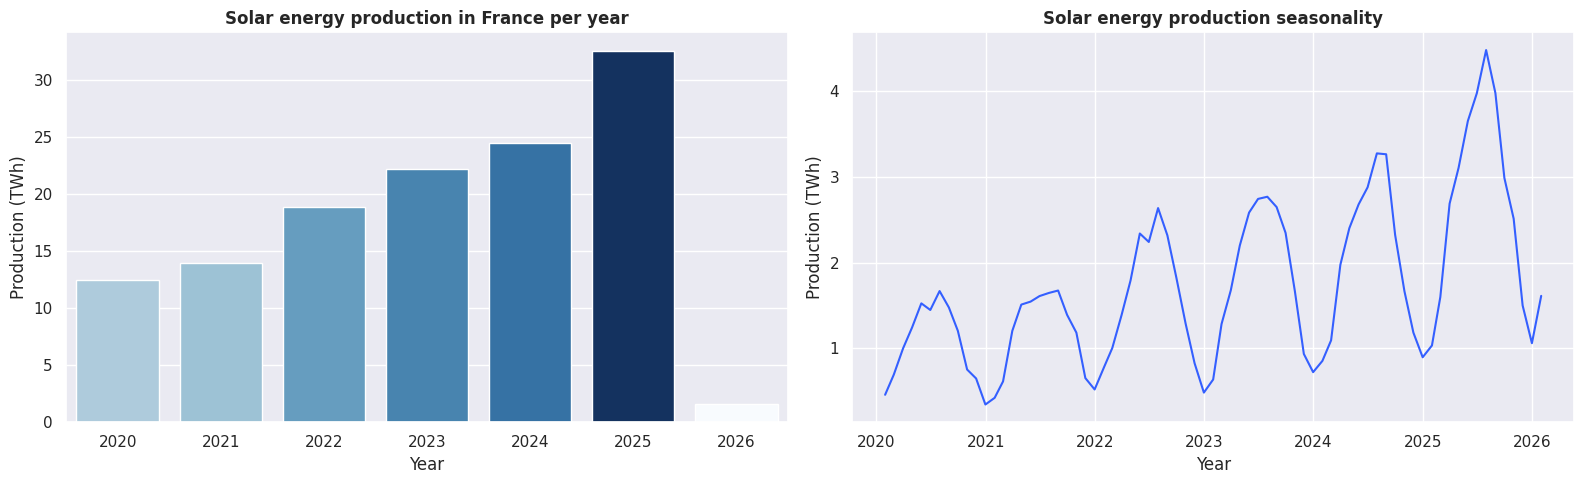

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Energy consumption
yearly_df = (solar_prod_df
             .groupby(solar_prod_df['date'].dt.to_period('Y'))['TWh'] # Using dt.to_period to get clean labels
             .sum()
             .reset_index()
             )

sns.barplot(data=yearly_df,
            x='date', 
            y='TWh',
            hue='TWh',
            palette='Blues', 
            ax=axes[0])

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Production (TWh)")
axes[0].set_title("Solar energy production in France per year", fontweight="bold")
axes[0].legend().remove()


monthly_df = (solar_prod_df
              .groupby(pd.Grouper(key='date', freq='ME'))['TWh']
              .sum()
              .reset_index()
              )

sns.lineplot(data=monthly_df,
            x='date', 
            y='TWh',
            palette='Blues',
            ax=axes[1])

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Production (TWh)")
axes[1].set_title("Solar energy production seasonality", fontweight="bold")


plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; D. Evolution of solar production by months

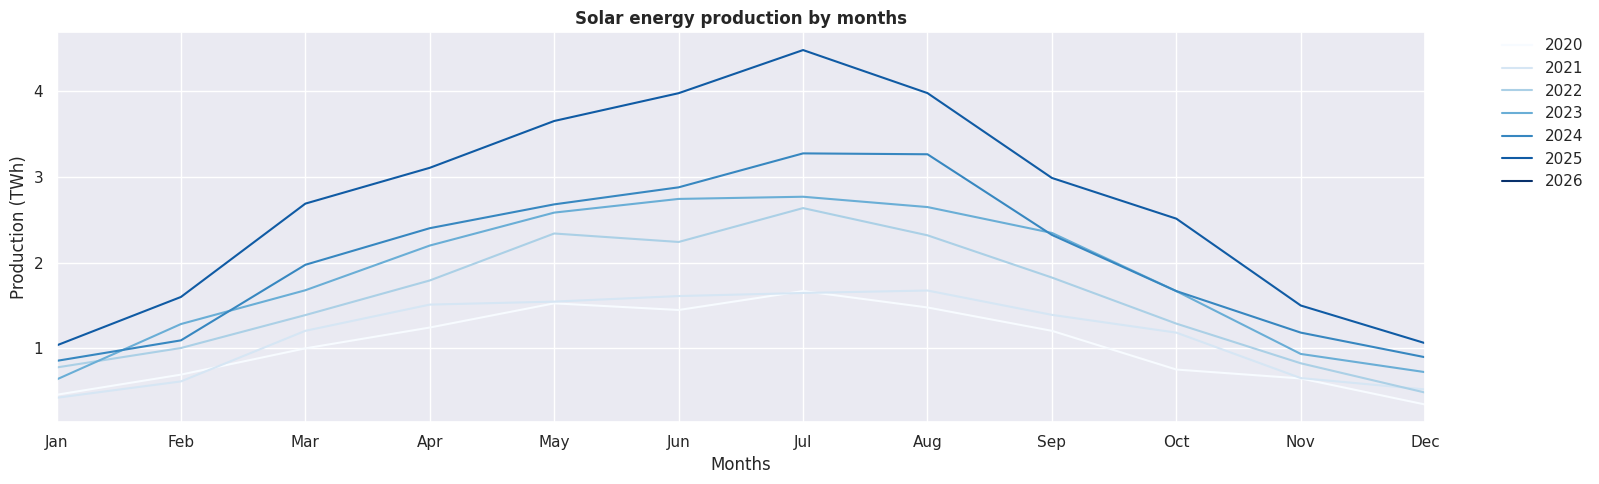

In [182]:
month_year_df = (solar_prod_df
              .groupby([solar_prod_df['date'].dt.to_period('M')])['TWh']
              .sum()
              .reset_index()
              )

month_year_df['date'] = month_year_df['date'].dt.to_timestamp()
month_year_df['year'] = month_year_df['date'].dt.year
month_year_df['month'] = month_year_df['date'].dt.month


fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=month_year_df,
                x='month', 
                y='TWh', 
                hue='year',
                palette='Blues',
                markers=True,
                dashes=False,
                ax=ax
                )

ax.set_xlabel("Months")
ax.set_ylabel("Production (TWh)")
ax.set_title("Solar energy production by months", fontweight="bold")

ax.margins(x=0) # To start the graph at the Y axis and leave no space

plt.legend(bbox_to_anchor=(1.12, 1), borderaxespad=0, frameon=False) # Put legend out of the graph

# Show all x labels and customize the labels
ax.set_xticks(range(1, 13)) # Setting up 12 marks
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; E. Solar production and atmospheric radiation relation

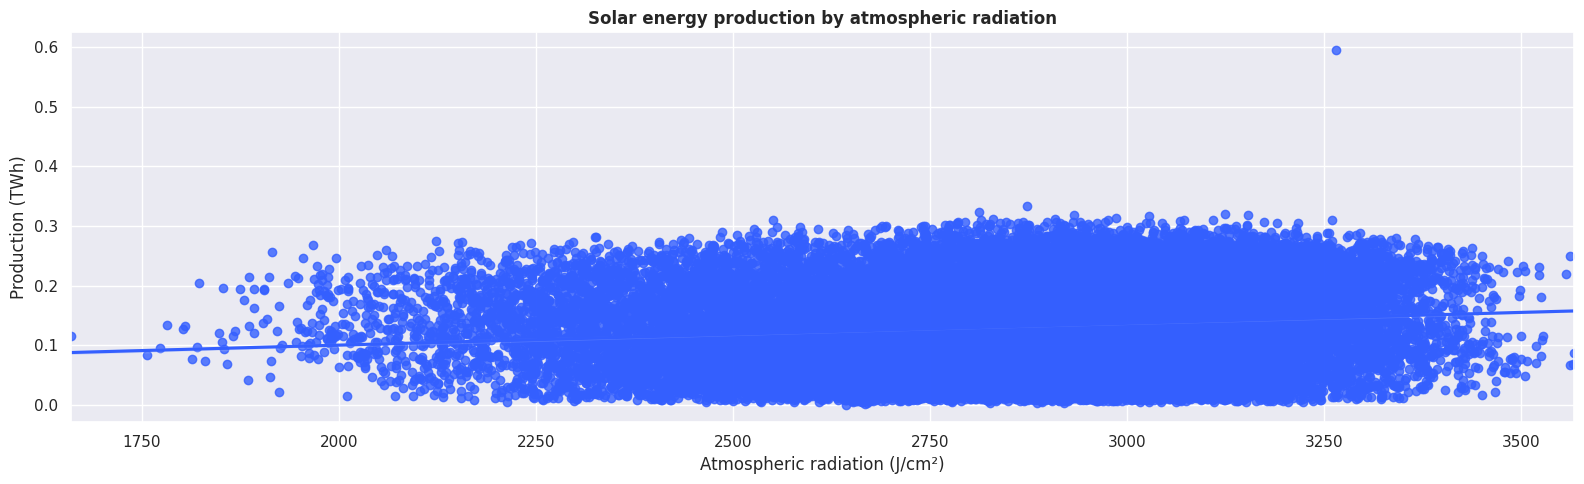

In [183]:
fig, ax = plt.subplots(figsize=(16, 5))

sns.regplot(data=solar_prod_df,
                x='atmospheric_radiation', 
                y='production_per_capacity', 
                ax=ax
                )

ax.set_xlabel("Atmospheric radiation (J/cm²)")
ax.set_ylabel("Production (TWh)")
ax.set_title("Solar energy production by atmospheric radiation", fontweight="bold")

ax.margins(x=0) # To start the graph at the Y axis and leave no space

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; F. Correlation between meteorological variables and solar production

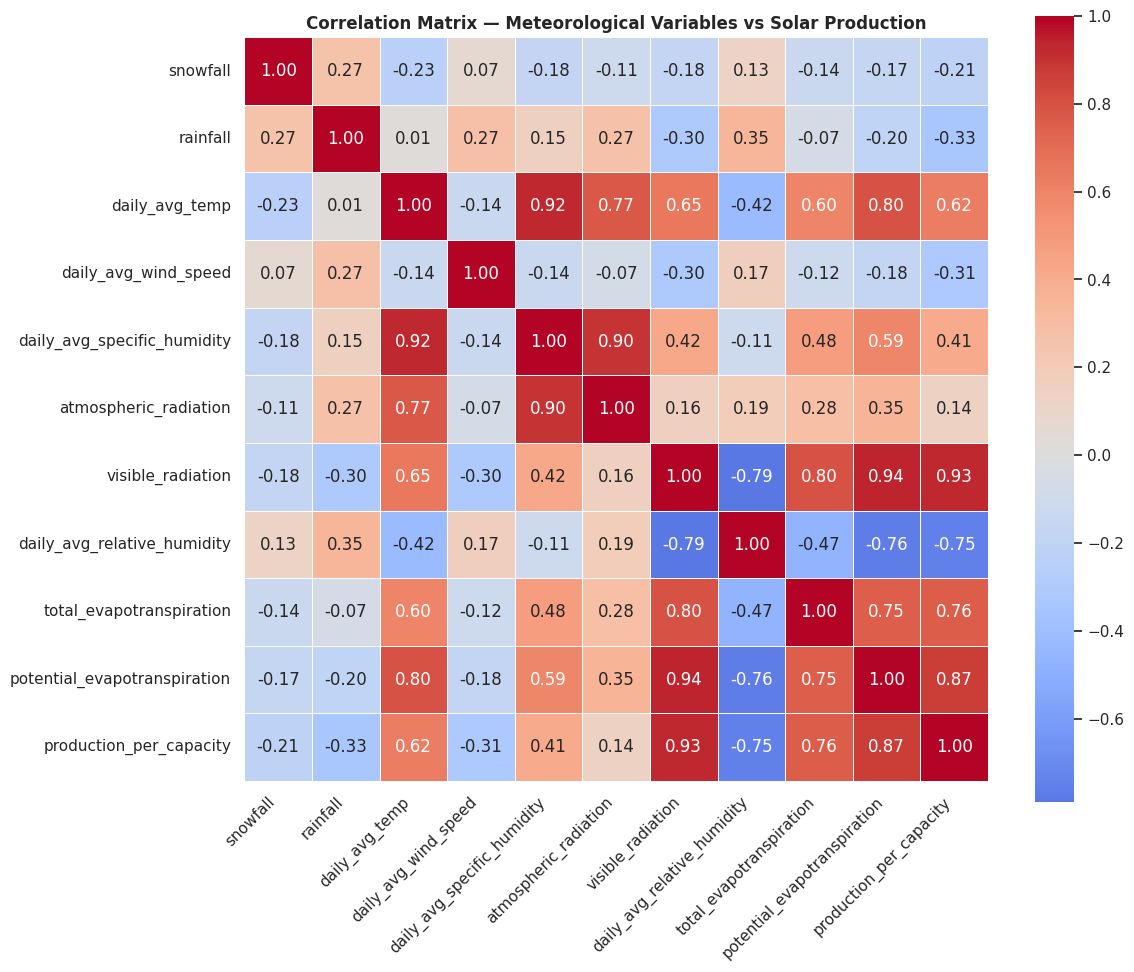

In [184]:
meteo_cols = ['snowfall', 'rainfall', 'daily_avg_temp', 'daily_avg_wind_speed', 
              'daily_avg_specific_humidity', 'atmospheric_radiation', 
              'visible_radiation', 'daily_avg_relative_humidity', 
              'total_evapotranspiration', 'potential_evapotranspiration', 'production_per_capacity'
              ]

corr = solar_prod_df[meteo_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=0.5, 
            ax=ax
            )

# Getting nice and clean x-axis, no legend colliding
ax.set_xticklabels(ax.get_xticklabels(),
                    rotation=45,
                    ha='right'
                    )
ax.set_title('Correlation Matrix — Meteorological Variables vs Solar Production', fontweight='bold')
plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; G. Top 4 correlations with production capacity

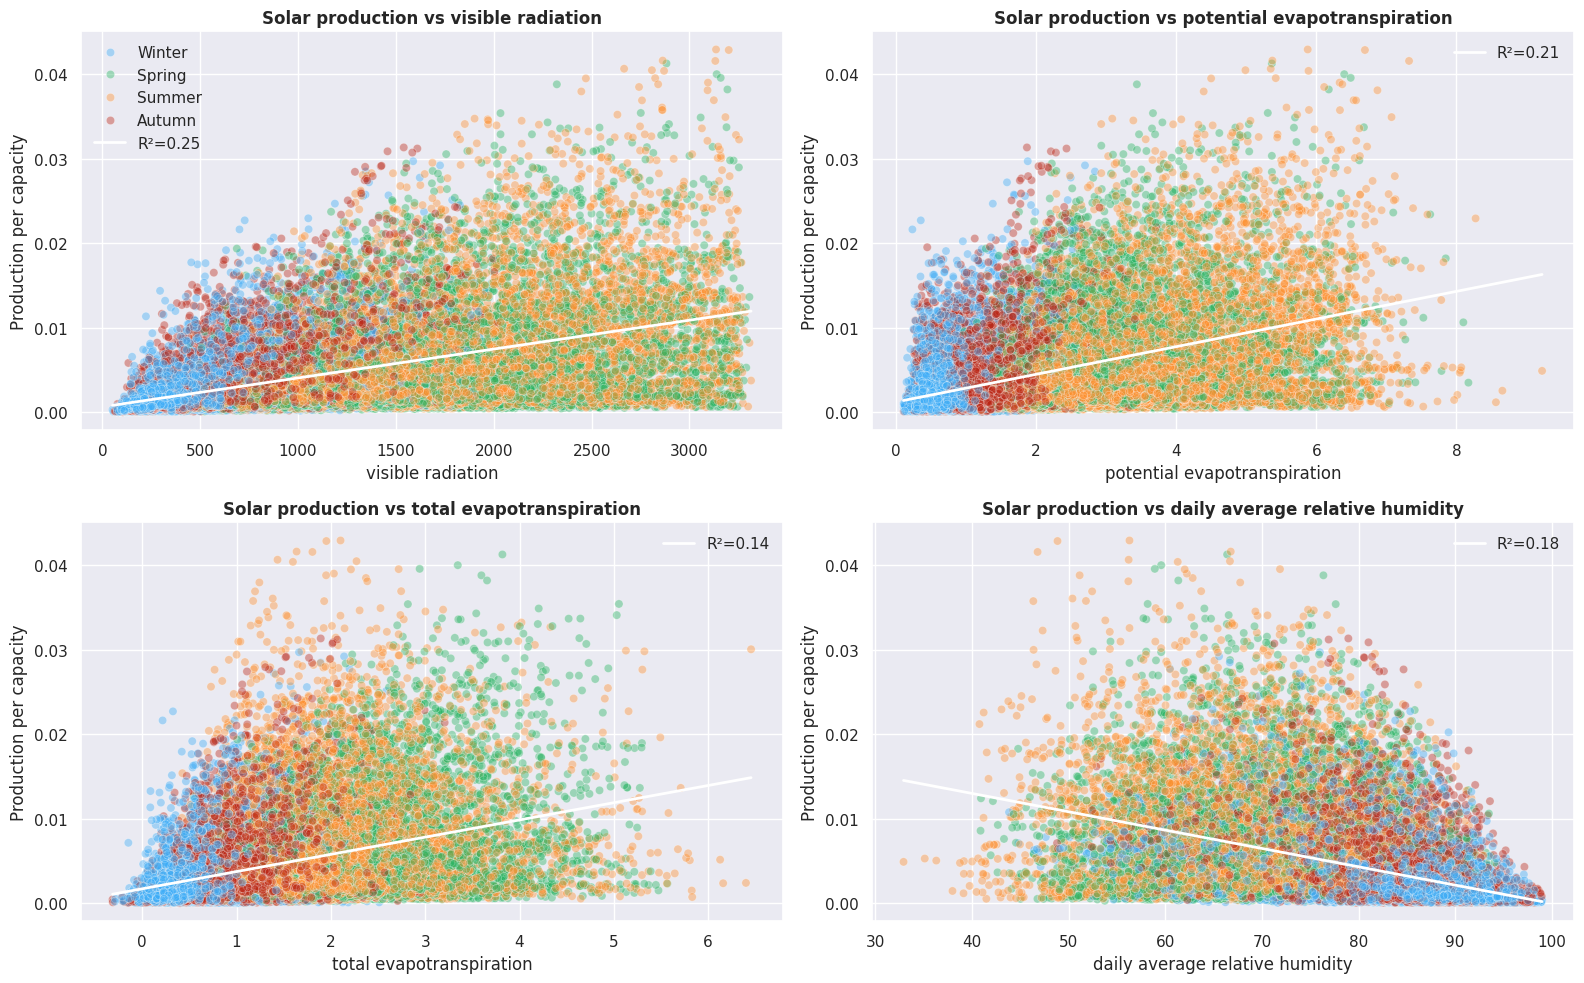

In [185]:
# Function to translate date into season
def get_season(date):
    m = date.month
    d = date.day
    if (m == 12 and d >= 21) or m in [1, 2] or (m == 3 and d < 20):
        return 'Winter'

    elif (m == 3 and d >= 20) or m in [4, 5] or (m == 6 and d < 21):
        return 'Spring'

    elif (m == 6 and d >= 21) or m in [7, 8] or (m == 9 and d < 23):
        return 'Summer'

    else:
        return 'Autumn'

season_palette = {
    'Winter': "#3CACF7",
    'Spring': "#25B360",
    'Summer': "#FF8F2D",
    'Autumn': "#BB2515",
}    

solar_prod_season_df = solar_prod_df.copy()
corr = solar_prod_season_df[meteo_cols].corr()
solar_prod_season_df['Season'] = solar_prod_season_df['date'].apply(get_season)
# Keep the top 4 correlated variables with TWh
top_corr = corr['production_per_capacity'].drop('production_per_capacity').abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()


for i, col in enumerate(top_corr):
    sns.scatterplot(
        data=solar_prod_season_df,
        x=col,
        y='TWh',
        hue='Season',
        hue_order=['Winter', 'Spring', 'Summer', 'Autumn'],
        palette=season_palette,
        alpha=0.4,
        ax=axes[i],
        legend=(i == 0)
    )
    x_clean = solar_prod_season_df[[col, 'TWh']].dropna()
    slope, intercept, r, *_ = stats.linregress(x_clean[col], x_clean['TWh'])
    x_range = np.linspace(x_clean[col].min(), x_clean[col].max(), 100)
    axes[i].plot(x_range, slope * x_range + intercept, color='white', linewidth=2, label=f'R²={r**2:.2f}')
    axes[i].legend(frameon=False)
    axes[i].set_title(f'Solar production vs {col.replace("_", " ").replace("avg", "average")}', fontweight='bold')
    axes[i].set_xlabel(f'{col.replace("_", " ").replace("avg", "average")}')
    axes[i].set_ylabel('Production per capacity')

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; H. Solar production distribution

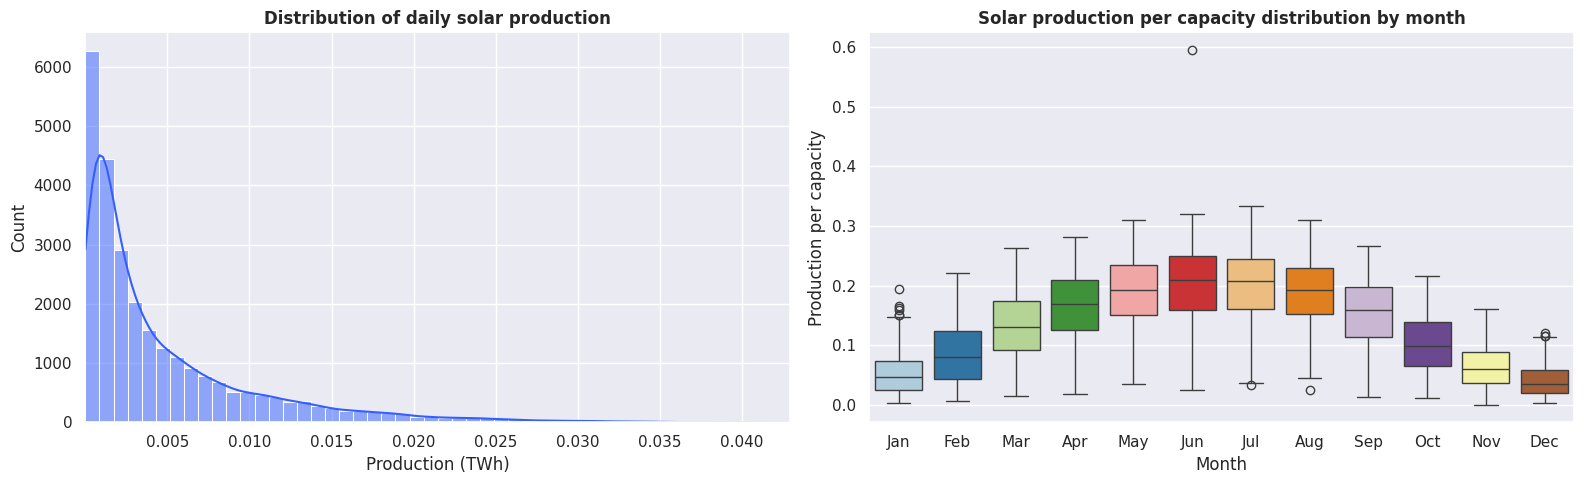

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(data=solar_prod_df, 
             x='TWh', 
             bins=50, 
             kde=True, 
             ax=axes[0], 
             color=palette[0]
             )

axes[0].set_title('Distribution of daily solar production', fontweight='bold')
axes[0].set_xlabel('Production (TWh)')
axes[0].margins(x=0) # To start the graph at the Y axis and leave no space

# Boxplot per month
sns.boxplot(data=solar_prod_df, 
            x=solar_prod_df['date'].dt.month, # Extract month for visualisation
            y='production_per_capacity', 
            palette='Paired', 
            ax=axes[1]
            )

axes[1].set_title('Solar production per capacity distribution by month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Production per capacity')
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()

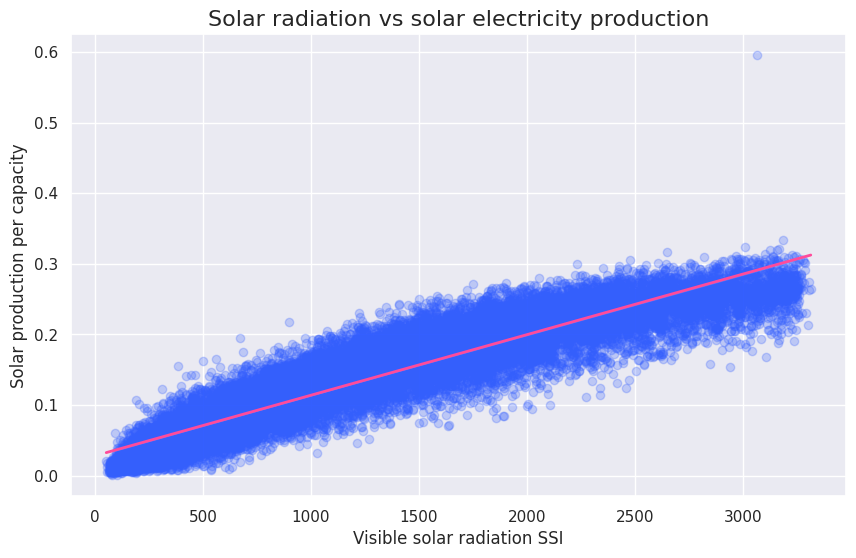

In [234]:
df = solar_prod_df.copy()

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="visible_radiation",
    y="production_per_capacity",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2, "color": ACCENT_RED}
)

plt.title("Solar radiation vs solar electricity production", fontsize=16)
plt.xlabel("Visible solar radiation SSI")
plt.ylabel("Solar production per capacity")
plt.show()

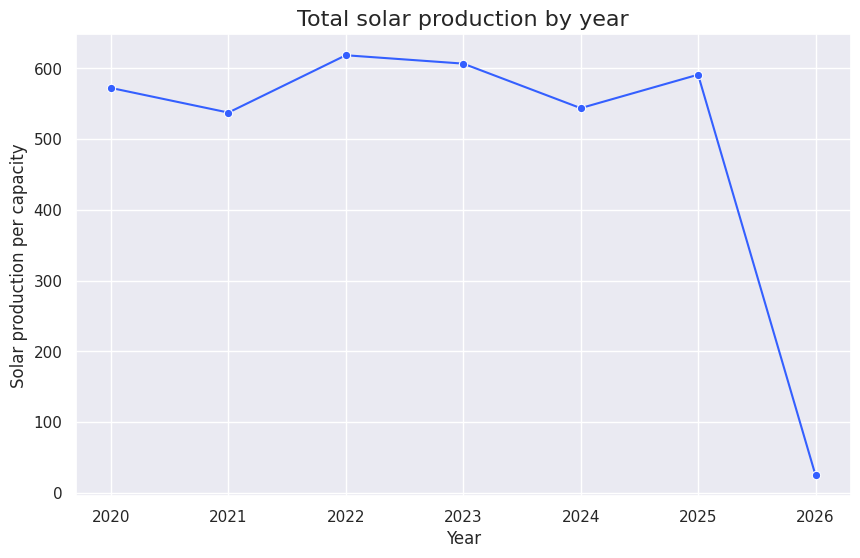

In [229]:
df["year"] = df["date"].dt.year

yearly = (
    df.groupby("year")["production_per_capacity"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly,
    x="year",
    y="production_per_capacity",
    marker="o"
)

plt.title("Total solar production by year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Solar production per capacity")
plt.show()

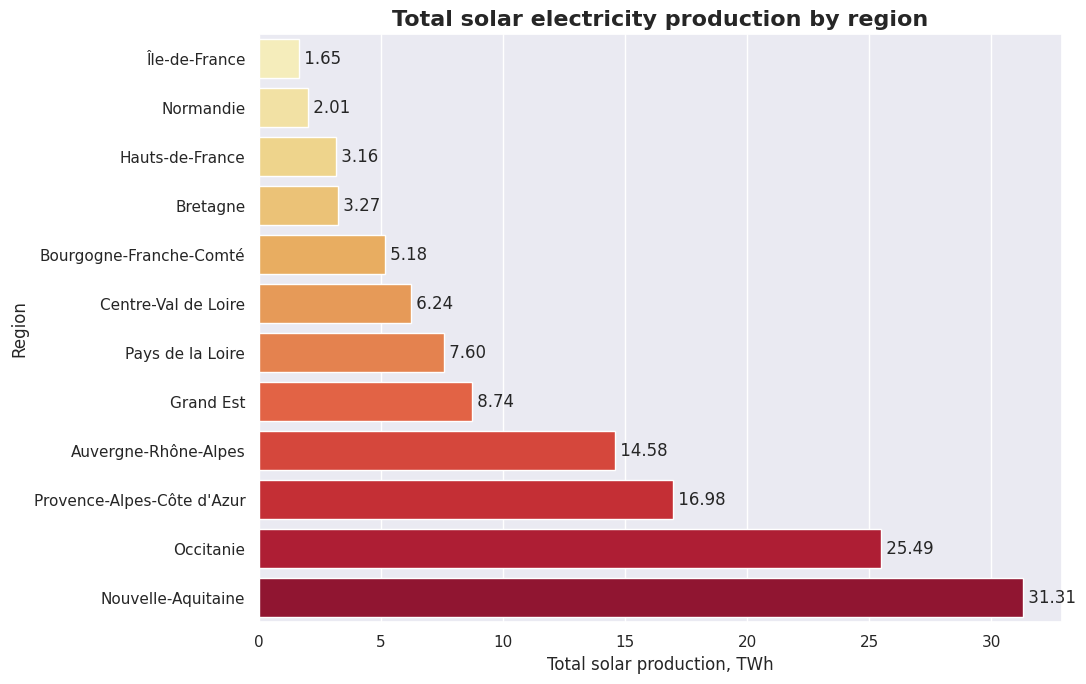

In [189]:
region_prod = (
    df.groupby("region", as_index=False)
    .agg(total_solar_TWh=("TWh", "sum"))
    .sort_values("total_solar_TWh", ascending=True)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=region_prod,
    x="total_solar_TWh",
    y="region",
    palette="YlOrRd"
)

plt.title("Total solar electricity production by region", fontsize=16, weight="bold")
plt.xlabel("Total solar production, TWh")
plt.ylabel("Region")

for index, value in enumerate(region_prod["total_solar_TWh"]):
    plt.text(value, index, f" {value:.2f}", va="center")

plt.tight_layout()
plt.show()

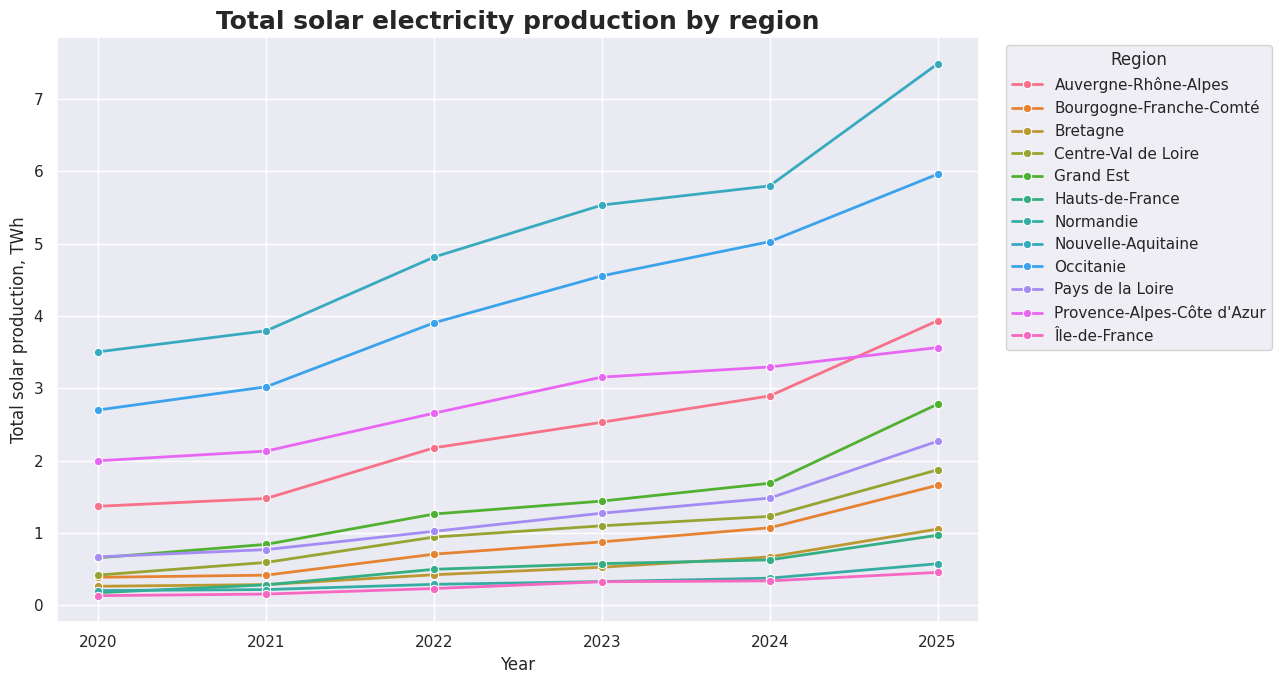

In [190]:
plot_df = df.copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year

# Remove incomplete year
plot_df = plot_df[plot_df["year"] < 2026]

year_region = (
    plot_df
    .groupby(["year", "region"], as_index=False)
    .agg(total_solar_TWh=("TWh", "sum"))
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=year_region,
    x="year",
    y="total_solar_TWh",
    hue="region",
    marker="o",
    linewidth=2
)

plt.title(
    "Total solar electricity production by region",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total solar production, TWh", fontsize=12)

plt.xticks(sorted(year_region["year"].unique()))

plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# 💹 3. Machine Learning

### &nbsp;&nbsp;&nbsp; A. Feature Engineering & Train/Test Split

In [191]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

ml_df["date"] = pd.to_datetime(ml_df["date"])

# Tri chronologique par région : nécessaire pour calculer les lags et moyennes
# glissantes correctement (on ne veut jamais mélanger les séries de deux régions)
ml_df = ml_df.sort_values(["region", "date"]).reset_index(drop=True)

# =========================
# 2. Lags J-1, J-2, J-3
# =========================

ml_df["radiation_J1"] = ml_df.groupby("region")["visible_radiation"].shift(1)
ml_df["radiation_J2"] = ml_df.groupby("region")["visible_radiation"].shift(2)
ml_df["radiation_J3"] = ml_df.groupby("region")["visible_radiation"].shift(3)

# =========================
# 3. Moyennes/sommes glissantes (7 jours, décalées de 1 jour pour ne pas
#    laisser la valeur du jour même fuiter dans sa propre moyenne)
# =========================

ml_df["radiation_7d_mean"] = (
    ml_df.groupby("region")["visible_radiation"]
         .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["temp_7d_mean"] = (
    ml_df.groupby("region")["daily_avg_temp"]
         .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df.groupby("region")["daily_avg_relative_humidity"]
         .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df.groupby("region")["rainfall"]
         .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# =========================
# 4. Saisonnalité (encodage cyclique du jour de l'année)
# =========================

ml_df["day_sin"] = np.sin(2 * np.pi * ml_df["date"].dt.dayofyear / 365)
ml_df["day_cos"] = np.cos(2 * np.pi * ml_df["date"].dt.dayofyear / 365)

# =========================
# 5. Cible J+1 par région
# =========================

ml_df["target"] = ml_df.groupby("region")["visible_radiation"].shift(-1)

# =========================
# 6. Suppression des NaN créés par les lags / moyennes glissantes / cible
# =========================

ml_df = ml_df.dropna().reset_index(drop=True)

# =========================
# 7. Tri final pour la logique temporelle (ordre chronologique global,
#    toutes régions confondues, avant le split train/test)
# =========================

# Pour des données temporelles, on n'utilise pas de df.sample(random_state):
# En effet, il ne faut pas utiliser de données futures pour prédire le passé
ml_df = ml_df.sort_values(["date", "region"]).reset_index(drop=True) 

print(f"Rows ready for modelling: {len(ml_df)}")


Rows ready for modelling: 26580


In [192]:
# =========================
# 8. Split train / test chronologique
#    Pas de randomisation : on ne prédit jamais le passé avec des données futures
# =========================

drop_cols = ["date", "solar", "TWh", "target", "installation_number", "capacity_power"]
# TWh et solar sont retirés des deux côtés (train et test) de façon cohérente pour
# tous les modèles : ce sont des dérivés de la production du jour même, redondants
# avec visible_radiation, et on ne veut pas qu'un modèle en profite pendant qu'un
# autre ne le peut pas.


# idem ici. On n'applique pas de randomisation avec des données temporelles.
# On se sert de l'existant pour prédire le future.
train = ml_df[ml_df["date"] < "2024-01-01"]
test = ml_df[ml_df["date"] >= "2024-01-01"]

X_train = train.drop(columns=drop_cols)
y_train = train["target"]

X_test = test.drop(columns=drop_cols)
y_test = test["target"]

print(f"Train: {len(X_train)} rows (before 2024-01-01)")
print(f"Test : {len(X_test)} rows (from 2024-01-01)")


Train: 17448 rows (before 2024-01-01)
Test : 9132 rows (from 2024-01-01)


In [193]:
# =========================
# 9. Préprocessing - construit une seule fois, réutilisé comme "plan" par les
#    modèles ci-dessous. Il n'est PAS ajusté (fit) ici : chaque modèle
#    l'intègre dans un Pipeline, ce qui le fait ré-ajuster à neuf sur chaque
#    pli de la cross-validation - pas de fuite entre le scaler et les folds.
# =========================

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print(f"Preprocessor ready: {len(numeric_features)} numeric + {len(categorical_features)} categorical features")


Preprocessor ready: 36 numeric + 1 categorical features


In [194]:
# =========================
# 10. Fonctions réutilisées par les modèles : évaluation
# =========================

# TimeSeriesSplit au lieu d'un simple K-Fold : chaque pli d'entraînement ne
# contient que des dates antérieures au pli de test correspondant.
tscv = TimeSeriesSplit(n_splits=5)

# Scoring multi-métrique + return_train_score=True : chaque GridSearchCV calcule
# R², MAE et RMSE sur chacun des 5 plis (train ET test), pas juste le RMSE moyen.
# On peut ensuite extraire la moyenne ET l'écart-type sur les 5 plis pour la
# combinaison d'hyperparamètres gagnante, afin de voir si une différence de score
# entre deux modèles est plus grande que le bruit naturel d'un pli à l'autre.
cv_scoring = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error",
    "neg_rmse": "neg_root_mean_squared_error"
}

# =========================
# Evaluation functions
# =========================
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    '''Predict on train/test and return the results 
    for the single-split comparison table.'''

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    return pd.DataFrame({
        "model": model_name,
        "set": ["train", "test"],
        "R2":   [r2_score(y_train, y_pred_train), r2_score(y_test, y_pred_test)],
        "MAE":  [mean_absolute_error(y_train, y_pred_train), mean_absolute_error(y_test, y_pred_test)],
        "RMSE": [mean_squared_error(y_train, y_pred_train) ** 0.5, mean_squared_error(y_test, y_pred_test) ** 0.5],
    })

# =========================
# Summary functions
# =========================
def cv_summary(gridsearch, model_name):
    '''Mean +/- std across the 5 TimeSeriesSplit folds, for the winning
    hyperparameter combination.'''

    idx = gridsearch.best_index_
    cvres = gridsearch.cv_results_

    return pd.DataFrame({
        "model": [model_name],
        "R2_train_mean":   [cvres["mean_train_r2"][idx]],
        "R2_train_std":    [cvres["std_train_r2"][idx]],
        "R2_test_mean":    [cvres["mean_test_r2"][idx]],
        "R2_test_std":     [cvres["std_test_r2"][idx]],
        "MAE_train_mean":  [-cvres["mean_train_neg_mae"][idx]],
        "MAE_train_std":   [cvres["std_train_neg_mae"][idx]],
        "MAE_test_mean":   [-cvres["mean_test_neg_mae"][idx]],
        "MAE_test_std":    [cvres["std_test_neg_mae"][idx]],
        "RMSE_train_mean": [-cvres["mean_train_neg_rmse"][idx]],
        "RMSE_train_std":  [cvres["std_train_neg_rmse"][idx]],
        "RMSE_test_mean":  [-cvres["mean_test_neg_rmse"][idx]],
        "RMSE_test_std":   [cvres["std_test_neg_rmse"][idx]],
    })

### &nbsp;&nbsp;&nbsp; B. Naive Baseline (persistence model)

Predicts tomorrow's radiation as simply **today's** radiation - no model at all.

In [195]:
y_pred_train_baseline = X_train["visible_radiation"]
y_pred_test_baseline = X_test["visible_radiation"]

result_baseline = pd.DataFrame({
    "model": "Naive Baseline",
    "set":  ["train", "test"],
    "R2":   [r2_score(y_train, y_pred_train_baseline), r2_score(y_test, y_pred_test_baseline)],
    "MAE":  [mean_absolute_error(y_train, y_pred_train_baseline), mean_absolute_error(y_test, y_pred_test_baseline)],
    "RMSE": [mean_squared_error(y_train, y_pred_train_baseline) ** 0.5, mean_squared_error(y_test, y_pred_test_baseline) ** 0.5],
})

display(result_baseline)

,model,set,R2,MAE,RMSE
0,Naive Baseline,train,0.710700,321.066312,443.019949
1,Naive Baseline,test,0.707943,316.477459,436.518235


In [196]:
# =========================
# Naive baseline - fold by fold (no GridSearchCV here, there's nothing to tune,
# so we replicate the same TimeSeriesSplit loop manually)
# =========================

baseline_fold_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train), start=1):
    y_train_fold = y_train.iloc[train_idx]
    y_test_fold = y_train.iloc[test_idx]

    y_pred_train_fold = X_train["visible_radiation"].iloc[train_idx]
    y_pred_test_fold = X_train["visible_radiation"].iloc[test_idx]

    baseline_fold_results.append({
        "fold": fold,
        "R2_train": r2_score(y_train_fold, y_pred_train_fold),
        "R2_test": r2_score(y_test_fold, y_pred_test_fold),
        "MAE_train": mean_absolute_error(y_train_fold, y_pred_train_fold),
        "MAE_test": mean_absolute_error(y_test_fold, y_pred_test_fold),
        "RMSE_train": mean_squared_error(y_train_fold, y_pred_train_fold) ** 0.5,
        "RMSE_test": mean_squared_error(y_test_fold, y_pred_test_fold) ** 0.5,
    })

baseline_fold_df = pd.DataFrame(baseline_fold_results)
display(baseline_fold_df)

result_baseline_cv = pd.DataFrame({
    "model": ["Naive Baseline"],
    "R2_train_mean":   [baseline_fold_df["R2_train"].mean()],
    "R2_train_std":    [baseline_fold_df["R2_train"].std()],
    "R2_test_mean":    [baseline_fold_df["R2_test"].mean()],
    "R2_test_std":     [baseline_fold_df["R2_test"].std()],
    "MAE_train_mean":  [baseline_fold_df["MAE_train"].mean()],
    "MAE_train_std":   [baseline_fold_df["MAE_train"].std()],
    "MAE_test_mean":   [baseline_fold_df["MAE_test"].mean()],
    "MAE_test_std":    [baseline_fold_df["MAE_test"].std()],
    "RMSE_train_mean": [baseline_fold_df["RMSE_train"].mean()],
    "RMSE_train_std":  [baseline_fold_df["RMSE_train"].std()],
    "RMSE_test_mean":  [baseline_fold_df["RMSE_test"].mean()],
    "RMSE_test_std":   [baseline_fold_df["RMSE_test"].std()],
})


,fold,R2_train,R2_test,MAE_train,MAE_test,RMSE_train,RMSE_test
0,1,0.634903,0.663325,379.900545,266.797777,514.711430,365.995381
1,2,0.703415,0.665944,323.349161,326.163140,446.587323,452.415290
2,3,0.692012,0.655846,324.287154,372.437277,448.538393,508.450236
3,4,0.696736,0.557009,336.324685,265.075807,464.241778,360.176702
4,5,0.701842,0.745133,322.074909,316.023329,445.378259,431.034895


### &nbsp;&nbsp;&nbsp; C. Linear Regression - No Feature Engineering

Only the raw weather variables from the dataset - no lags, no rolling stats, no seasonality.

In [197]:
engineered_cols = [
    "radiation_J1", "radiation_J2", "radiation_J3",
    "radiation_7d_mean", "temp_7d_mean", "humidity_7d_mean", "rainfall_7d_sum",
    "day_sin", "day_cos"
]

X_train_raw = X_train.drop(columns=engineered_cols)
X_test_raw = X_test.drop(columns=engineered_cols)

numeric_features_raw = X_train_raw.select_dtypes(include=["int64", "float64"]).columns
categorical_features_raw = X_train_raw.select_dtypes(include=["object"]).columns

preprocessor_raw = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features_raw),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features_raw)
])

pipe_lr_raw = Pipeline(steps=[
    ("preprocessor", preprocessor_raw),
    ("model", LinearRegression())
])

lr_params = {
    "model__fit_intercept": [True, False]
}

gridsearch_lr_raw = GridSearchCV(
    pipe_lr_raw, param_grid=lr_params, cv=tscv,
    scoring=cv_scoring, refit="neg_rmse", return_train_score=True, n_jobs=-1
)
gridsearch_lr_raw.fit(X_train_raw, y_train)

print("Best hyperparameters :", gridsearch_lr_raw.best_params_)
print("Best CV RMSE         :", round(-gridsearch_lr_raw.best_score_, 3))

model_lr_raw = gridsearch_lr_raw.best_estimator_

result_lr_raw = evaluate_model(model_lr_raw, "LR - No feature engineering", X_train_raw, y_train, X_test_raw, y_test)
result_lr_raw_cv = cv_summary(gridsearch_lr_raw, "LR - No feature engineering")

display(result_lr_raw)

Best hyperparameters : {'model__fit_intercept': True}
Best CV RMSE         : 405.913


,model,set,R2,MAE,RMSE
0,LR - No feature engineering,train,0.765880,302.925325,398.536867
1,LR - No feature engineering,test,0.759523,301.992183,396.100717


### &nbsp;&nbsp;&nbsp; D. Linear Regression - With Lags

Check the best lag combination for the model.

#### &nbsp;&nbsp;&nbsp; 1 - ACF

In [198]:
national_daily = (
    ml_df
    .groupby("date")["visible_radiation"]
    .mean()
    .reset_index()
    .sort_values("date")
)

print(f"National daily series: {len(national_daily)} points")


National daily series: 2215 points


In [199]:
# ACF computation

acf_values, confint = acf(
    national_daily["visible_radiation"],
    nlags=30,
    alpha=0.05
)

acf_df = pd.DataFrame({
    "Lag": range(len(acf_values)),
    "ACF": acf_values,
    "IC_inf": confint[:,0],
    "IC_sup": confint[:,1]
})

display(acf_df.round(3))


,Lag,ACF,IC_inf,IC_sup
0,0,1.000,1.000,1.000
1,1,0.925,0.883,0.966
2,2,0.858,0.789,0.926
3,3,0.820,0.735,0.905
4,4,0.796,0.698,0.894
5,5,0.778,0.669,0.886
6,6,0.767,0.649,0.885
7,7,0.759,0.633,0.885
8,8,0.756,0.623,0.890
9,9,0.752,0.611,0.893


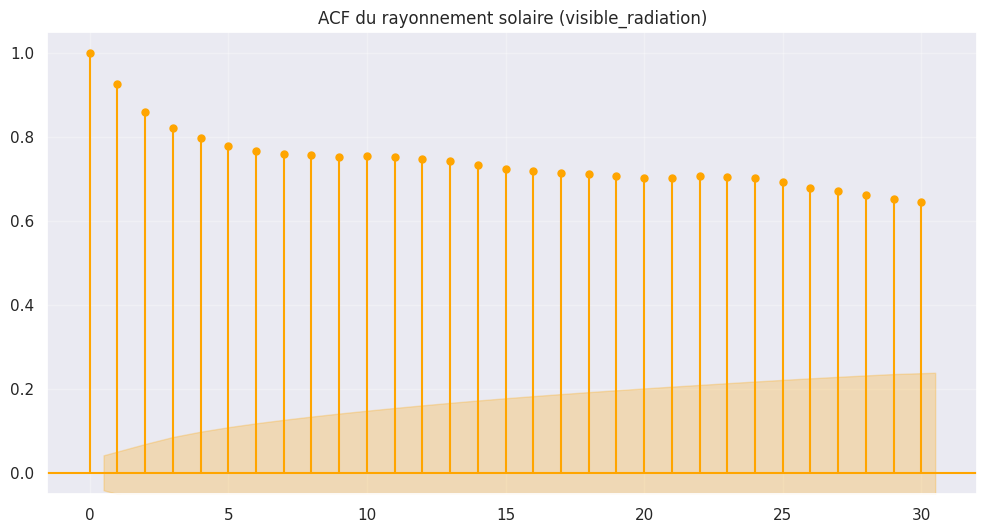

In [200]:
# ACF graph

fig, ax = plt.subplots(figsize=(12,6))

plot_acf(
    national_daily["visible_radiation"],
    lags=30,
    ax=ax
)

# Couleur orange
for line in ax.lines:
    line.set_color("orange")

for collection in ax.collections:
    collection.set_color("orange")

# Zoom vertical
ax.set_ylim(-0.05, 1.05)

# Grille
ax.grid(True, alpha=0.3)

# Titre plus explicite
ax.set_title(
    "ACF du rayonnement solaire (visible_radiation)"
)

plt.show()


#### &nbsp;&nbsp;&nbsp; 2 - PACF

In [201]:
# PACF computation

pacf_values, confint = pacf(
    national_daily["visible_radiation"],
    nlags=30,
    alpha=0.05
)

pacf_df = pd.DataFrame({
    "Lag": range(len(pacf_values)),
    "PACF": pacf_values,
    "IC_inf": confint[:,0],
    "IC_sup": confint[:,1]
})

display(pacf_df.round(3))


,Lag,PACF,IC_inf,IC_sup
0,0,1.000,1.000,1.000
1,1,0.925,0.884,0.967
2,2,0.018,-0.024,0.059
3,3,0.167,0.126,0.209
4,4,0.105,0.064,0.147
5,5,0.073,0.031,0.114
6,6,0.104,0.062,0.146
7,7,0.066,0.025,0.108
8,8,0.100,0.058,0.141
9,9,0.046,0.004,0.087


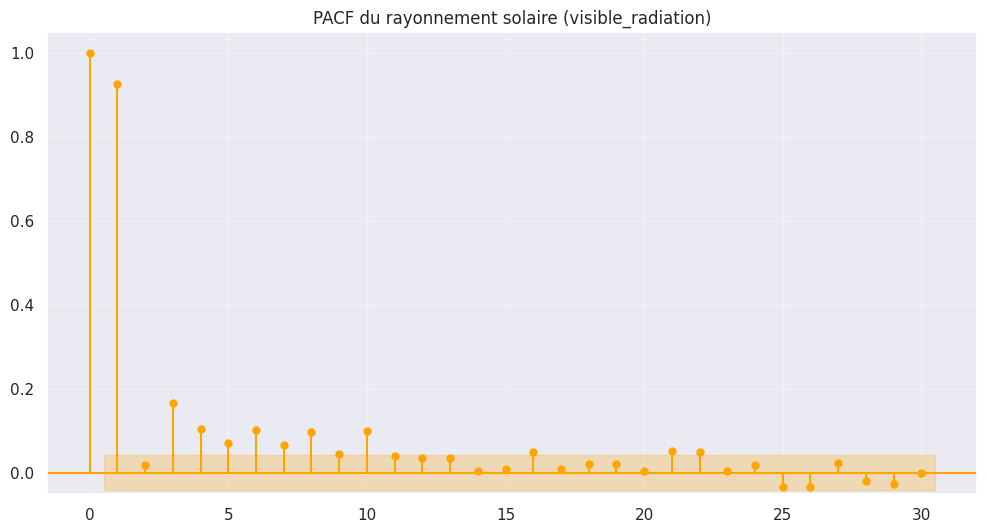

In [202]:
# PACF graph

fig, ax = plt.subplots(figsize=(12,6))

plot_pacf(
    national_daily["visible_radiation"],
    lags=30,
    ax=ax
)

# Couleur orange
for line in ax.lines:
    line.set_color("orange")

for collection in ax.collections:
    collection.set_color("orange")

# Zoom vertical
ax.set_ylim(-0.05, 1.05)

# Grille
ax.grid(True, alpha=0.3)

# Titre plus explicite
ax.set_title(
    "PACF du rayonnement solaire (visible_radiation)"
)

plt.show()


#### &nbsp;&nbsp;&nbsp; 3 - Chosing daily lags

In [203]:
# Testing different lags: 3, 5 and 10

def build_lagged_features(df, n_lags):
    '''Test a configurable number of lags'''
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["region", "date"]).reset_index(drop=True)

    for lag in range(1, n_lags + 1):
        df[f"radiation_J{lag}"] = df.groupby("region")["visible_radiation"].shift(lag)

    df["radiation_7d_mean"] = df.groupby("region")["visible_radiation"].transform(lambda x: x.shift(1).rolling(7).mean())
    df["temp_7d_mean"] = df.groupby("region")["daily_avg_temp"].transform(lambda x: x.shift(1).rolling(7).mean())
    df["humidity_7d_mean"] = df.groupby("region")["daily_avg_relative_humidity"].transform(lambda x: x.shift(1).rolling(7).mean())
    df["rainfall_7d_sum"] = df.groupby("region")["rainfall"].transform(lambda x: x.shift(1).rolling(7).sum())

    df["target"] = df.groupby("region")["visible_radiation"].shift(-1)

    df = df.dropna().reset_index(drop=True)
    df = df.sort_values(["date", "region"]).reset_index(drop=True)

    return df


results_lags_test = []
results_lags_cv = []

for n_lags in [3, 5, 10, 30]:

    df_lag = build_lagged_features(solar_prod_df, n_lags)

    train_lag = df_lag[df_lag["date"] < "2024-01-01"]
    test_lag = df_lag[df_lag["date"] >= "2024-01-01"]

    X_train_nlags = train_lag.drop(columns=drop_cols)
    y_train_nlags = train_lag["target"]
    X_test_nlags = test_lag.drop(columns=drop_cols)
    y_test_nlags = test_lag["target"]

    numeric_features_nlags = X_train_nlags.select_dtypes(include=["int64", "float64"]).columns
    categorical_features_nlags = X_train_nlags.select_dtypes(include=["object"]).columns

    preprocessor_nlags = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features_nlags),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features_nlags)
    ])

    pipe_lr_nlags = Pipeline(steps=[
        ("preprocessor", preprocessor_nlags),
        ("model", LinearRegression())
    ])

    gridsearch_nlags = GridSearchCV(
        pipe_lr_nlags, param_grid=lr_params, cv=tscv,
        scoring=cv_scoring, refit="neg_rmse", return_train_score=True, n_jobs=-1
    )
    gridsearch_nlags.fit(X_train_nlags, y_train_nlags)

    print(f"--- {n_lags} lags ---")
    print("Best hyperparameters :", gridsearch_nlags.best_params_)
    print("Best CV RMSE         :", round(-gridsearch_nlags.best_score_, 3))
    print()

    model_nlags = gridsearch_nlags.best_estimator_

    result_test = evaluate_model(model_nlags, f"LR - {n_lags} lags", X_train_nlags, y_train_nlags, X_test_nlags, y_test_nlags)
    result_cv = cv_summary(gridsearch_nlags, f"LR - {n_lags} lags")

    results_lags_test.append(result_test)
    results_lags_cv.append(result_cv)

    print()

results_lags_test_df = pd.concat(results_lags_test).reset_index(drop=True)
results_lags_cv_df = pd.concat(results_lags_cv).reset_index(drop=True)

# Print clean table for better view
display(results_lags_test_df)
display(results_lags_cv_df)

--- 3 lags ---
Best hyperparameters : {'model__fit_intercept': True}
Best CV RMSE         : 390.107


--- 5 lags ---
Best hyperparameters : {'model__fit_intercept': True}
Best CV RMSE         : 390.034


--- 10 lags ---
Best hyperparameters : {'model__fit_intercept': True}
Best CV RMSE         : 386.803


--- 30 lags ---
Best hyperparameters : {'model__fit_intercept': True}
Best CV RMSE         : 393.898




,model,set,R2,MAE,RMSE
0,LR - 3 lags,train,0.777739,294.373410,388.311321
1,LR - 3 lags,test,0.777078,288.662018,381.369226
2,LR - 5 lags,train,0.777949,294.327865,388.128461
3,LR - 5 lags,test,0.777188,288.605798,381.274648
4,LR - 10 lags,train,0.780116,293.433570,386.173000
5,LR - 10 lags,test,0.779160,287.055769,379.583850
6,LR - 30 lags,train,0.782931,293.001094,383.721445
7,LR - 30 lags,test,0.781289,286.053554,377.749723


,model,R2_train_mean,R2_train_std,R2_test_mean,R2_test_std,MAE_train_mean,MAE_train_std,MAE_test_mean,MAE_test_std,RMSE_train_mean,RMSE_train_std,RMSE_test_mean,RMSE_test_std
0,LR - 3 lags,0.759000,0.015685,0.704464,0.071721,310.038862,17.911174,300.540326,35.650523,406.329726,19.731446,390.106521,45.132995
1,LR - 5 lags,0.759542,0.015246,0.704792,0.070731,309.993036,17.860777,300.509015,35.869754,405.879538,19.406610,390.034292,45.494868
2,LR - 10 lags,0.760156,0.017290,0.710644,0.066146,309.743923,18.473866,298.202048,37.832951,404.390589,19.613290,386.802928,47.159975
3,LR - 30 lags,0.754043,0.031188,0.693240,0.098568,311.214630,20.780013,304.283772,43.935799,403.001828,20.360957,393.898043,51.652963


#### &nbsp;&nbsp;&nbsp; 4 - Linear Regression with 3 days lag

In [204]:
season_cols = ["day_sin", "day_cos"]

X_train_lags = X_train.drop(columns=season_cols)
X_test_lags = X_test.drop(columns=season_cols)

numeric_features_lags = X_train_lags.select_dtypes(include=["int64", "float64"]).columns
categorical_features_lags = X_train_lags.select_dtypes(include=["object"]).columns

preprocessor_lags = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features_lags),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features_lags)
])

pipe_lr_lags = Pipeline(steps=[
    ("preprocessor", preprocessor_lags),
    ("model", LinearRegression())
])

gridsearch_lr_lags = GridSearchCV(
    pipe_lr_lags, param_grid=lr_params, cv=tscv,
    scoring=cv_scoring, refit="neg_rmse", return_train_score=True, n_jobs=-1
)
gridsearch_lr_lags.fit(X_train_lags, y_train)

print("Best hyperparameters :", gridsearch_lr_lags.best_params_)
print("Best CV RMSE         :", round(-gridsearch_lr_lags.best_score_, 3))

model_lr_lags = gridsearch_lr_lags.best_estimator_

result_lr_lags = evaluate_model(model_lr_lags, "LR - With lags", X_train_lags, y_train, X_test_lags, y_test)
result_lr_lags_cv = cv_summary(gridsearch_lr_lags, "LR - With lags")

display(result_lr_lags)

Best hyperparameters : {'model__fit_intercept': True}
Best CV RMSE         : 390.107


,model,set,R2,MAE,RMSE
0,LR - With lags,train,0.777739,294.373410,388.311321
1,LR - With lags,test,0.777078,288.662018,381.369226


#### &nbsp;&nbsp;&nbsp; 5 - Testing a yearly lag (J-365)

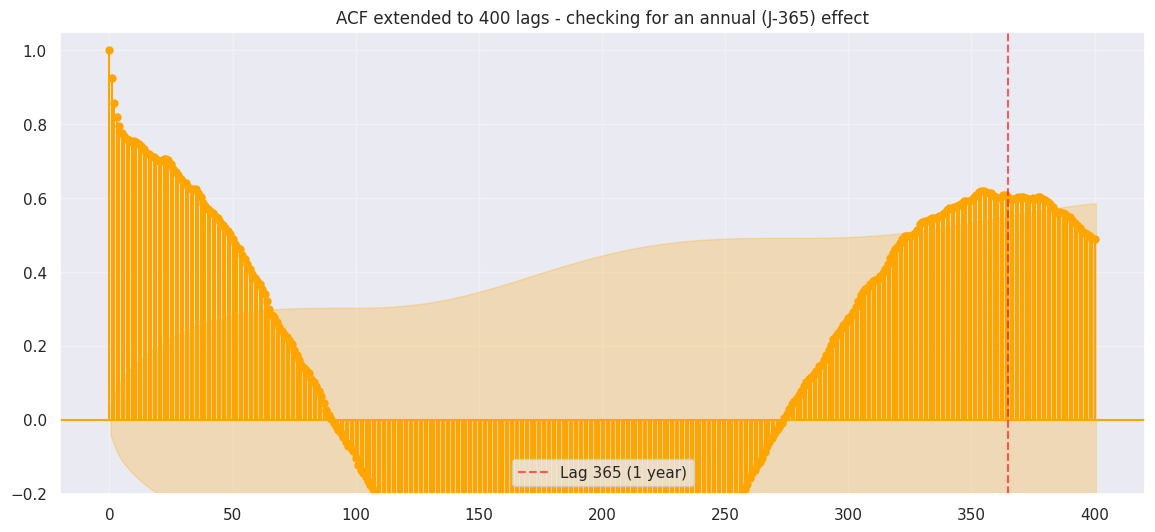

In [205]:
# =========================
# Extended ACF - check for an annual bump around lag 365
# =========================

fig, ax = plt.subplots(figsize=(14, 6))

plot_acf(
    national_daily["visible_radiation"],
    lags=400,
    ax=ax
)

# Couleur orange
for line in ax.lines:
    line.set_color("orange")

for collection in ax.collections:
    collection.set_color("orange")

ax.axvline(365, color="red", linestyle="--", alpha=0.6, label="Lag 365 (1 year)")
ax.legend()
ax.set_ylim(-0.2, 1.05)
ax.grid(True, alpha=0.3)
ax.set_title("ACF extended to 400 lags - checking for an annual (J-365) effect")

plt.show()


In [206]:
# =========================
# Build features with J-365 added
# =========================

df_j365 = solar_prod_df.copy()
df_j365["date"] = pd.to_datetime(df_j365["date"])
df_j365 = df_j365.sort_values(["region", "date"]).reset_index(drop=True)

for lag in [1, 2, 3]:
    df_j365[f"radiation_J{lag}"] = df_j365.groupby("region")["visible_radiation"].shift(lag)

df_j365["radiation_7d_mean"] = df_j365.groupby("region")["visible_radiation"].transform(lambda x: x.shift(1).rolling(7).mean())
df_j365["temp_7d_mean"] = df_j365.groupby("region")["daily_avg_temp"].transform(lambda x: x.shift(1).rolling(7).mean())
df_j365["humidity_7d_mean"] = df_j365.groupby("region")["daily_avg_relative_humidity"].transform(lambda x: x.shift(1).rolling(7).mean())
df_j365["rainfall_7d_sum"] = df_j365.groupby("region")["rainfall"].transform(lambda x: x.shift(1).rolling(7).sum())

# Year-ago lag
df_j365["radiation_J365"] = df_j365.groupby("region")["visible_radiation"].shift(365)

df_j365["target"] = df_j365.groupby("region")["visible_radiation"].shift(-1)

df_j365 = df_j365.dropna().reset_index(drop=True)
df_j365 = df_j365.sort_values(["date", "region"]).reset_index(drop=True)

print(f"Rows available with J365: {len(df_j365)}")
print(f"Rows available without J365 (3-lag model): {len(X_train_lags) + len(X_test_lags)}")


Rows available with J365: 22284
Rows available without J365 (3-lag model): 26580


In [207]:
train_j365 = df_j365[df_j365["date"] < "2024-01-01"]
test_j365 = df_j365[df_j365["date"] >= "2024-01-01"]

X_train_j365 = train_j365.drop(columns=drop_cols)
y_train_j365 = train_j365["target"]
X_test_j365 = test_j365.drop(columns=drop_cols)
y_test_j365 = test_j365["target"]

numeric_features_j365 = X_train_j365.select_dtypes(include=["int64", "float64"]).columns
categorical_features_j365 = X_train_j365.select_dtypes(include=["object"]).columns

preprocessor_j365 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features_j365),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features_j365)
])

pipe_lr_j365 = Pipeline(steps=[
    ("preprocessor", preprocessor_j365),
    ("model", LinearRegression())
])

gridsearch_j365 = GridSearchCV(
    pipe_lr_j365, param_grid=lr_params, cv=tscv,
    scoring=cv_scoring, refit="neg_rmse", return_train_score=True, n_jobs=-1
)
gridsearch_j365.fit(X_train_j365, y_train_j365)

print("Best hyperparameters :", gridsearch_j365.best_params_)
print("Best CV RMSE         :", round(-gridsearch_j365.best_score_, 3))

model_j365 = gridsearch_j365.best_estimator_

result_j365 = evaluate_model(model_j365, "LR - With lags + J365", X_train_j365, y_train_j365, X_test_j365, y_test_j365)
result_j365_cv = cv_summary(gridsearch_j365, "LR - With lags + J365")

display(result_j365)


Best hyperparameters : {'model__fit_intercept': False}
Best CV RMSE         : 400.629


,model,set,R2,MAE,RMSE
0,LR - With lags + J365,train,0.767957,301.626453,392.289965
1,LR - With lags + J365,test,0.762729,301.587500,393.451442


**Comparison: 3-lag model with vs. without J-365** (single split, then mean ± std across the 5 folds).

In [208]:
comparison_j365 = pd.concat([result_lr_lags, result_j365]).reset_index(drop=True)
display(comparison_j365)

comparison_j365_cv = pd.concat([result_lr_lags_cv, result_j365_cv]).reset_index(drop=True)
display(comparison_j365_cv)

print("Results are worst with the 365 lag, maybe because there's less data to train on.")
print("We're not keeping it.")

,model,set,R2,MAE,RMSE
0,LR - With lags,train,0.777739,294.373410,388.311321
1,LR - With lags,test,0.777078,288.662018,381.369226
2,LR - With lags + J365,train,0.767957,301.626453,392.289965
3,LR - With lags + J365,test,0.762729,301.587500,393.451442


,model,R2_train_mean,R2_train_std,R2_test_mean,R2_test_std,MAE_train_mean,MAE_train_std,MAE_test_mean,MAE_test_std,RMSE_train_mean,RMSE_train_std,RMSE_test_mean,RMSE_test_std
0,LR - With lags,0.759000,0.015685,0.704464,0.071721,310.038862,17.911174,300.540326,35.650523,406.329726,19.731446,390.106521,45.132995
1,LR - With lags + J365,0.744519,0.016792,0.751643,0.036862,311.273676,8.054752,309.979678,20.768972,402.169220,8.095268,400.629456,26.450253


Results are worst with the 365 lag, maybe because there's less data to train on.
We're not keeping it.


### &nbsp;&nbsp;&nbsp; E. Linear Regression - With Lags + Seasonality (full feature set)

Adds `day_sin`/`day_cos` on top.

In [209]:
lr_params_full = {
    "model__fit_intercept": [True, False]
}

pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

gridsearch_lr = GridSearchCV(
    pipe_lr,
    param_grid=lr_params_full,
    cv=tscv,
    scoring=cv_scoring,
    refit="neg_rmse",
    return_train_score=True,
    n_jobs=-1
)

gridsearch_lr.fit(X_train, y_train)

print("Best hyperparameters :", gridsearch_lr.best_params_)
print("Best CV RMSE         :", round(-gridsearch_lr.best_score_, 3))

model_lr = gridsearch_lr.best_estimator_

result_lr = evaluate_model(model_lr, "Linear Regression", X_train, y_train, X_test, y_test)
result_lr_cv = cv_summary(gridsearch_lr, "Linear Regression")

display(result_lr)

Best hyperparameters : {'model__fit_intercept': True}
Best CV RMSE         : 379.232


,model,set,R2,MAE,RMSE
0,Linear Regression,train,0.790777,287.636792,376.750462
1,Linear Regression,test,0.792355,278.943283,368.069532


In [210]:
# Importance des variables (coefficients du meilleur modèle)

feature_names_full = model_lr.named_steps["preprocessor"].get_feature_names_out()

coefficients = pd.DataFrame({
    "Variable": feature_names_full,
    "Coefficient": model_lr.named_steps["model"].coef_
}).sort_values(by="Coefficient", key=abs, ascending=False).reset_index(drop=True)

display(coefficients)


,Variable,Coefficient
0,num__effective_rainfall,18508.264453
1,num__rainfall,-16925.564169
2,num__total_evapotranspiration,4356.149398
3,num__snowfall,-2621.358615
4,num__daily_avg_snow_water,1100.387286
5,num__snow_water_equivalent_6h,-1075.409413
6,num__max_snow_depth,814.868600
7,num__daily_avg_temp,-739.153282
8,num__daily_avg_soil_moisture_index,637.241511
9,num__daily_avg_snow_depth,-636.894157


### &nbsp;&nbsp;&nbsp; F. Lasso Regression (L1 regularization)

In [211]:
lasso_params = {
    "model__alpha": [1, 2, 3, 4, 5, 10, 20, 50, 100],
    "model__fit_intercept": [True, False]
}

pipe_lasso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=20000))
])

gridsearch_lasso = GridSearchCV(
    pipe_lasso,
    param_grid=lasso_params,
    cv=tscv,
    scoring=cv_scoring,
    refit="neg_rmse",
    return_train_score=True,
    n_jobs=-1
)

gridsearch_lasso.fit(X_train, y_train)

print("Best hyperparameters :", gridsearch_lasso.best_params_)
print("Best CV RMSE         :", round(-gridsearch_lasso.best_score_, 3))

model_lasso = gridsearch_lasso.best_estimator_

result_lasso = evaluate_model(model_lasso, "Lasso", X_train, y_train, X_test, y_test)
result_lasso_cv = cv_summary(gridsearch_lasso, "Lasso")

display(result_lasso)

Best hyperparameters : {'model__alpha': 2, 'model__fit_intercept': True}
Best CV RMSE         : 368.597


,model,set,R2,MAE,RMSE
0,Lasso,train,0.786361,291.084154,380.705495
1,Lasso,test,0.788289,281.542514,371.655803


In [212]:
# Importance des variables (coefficients du meilleur modèle) + variables mises à zéro

feature_names_lasso = model_lasso.named_steps["preprocessor"].get_feature_names_out()

coefficients_lasso = pd.DataFrame({
    "Variable": feature_names_lasso,
    "Coefficient": model_lasso.named_steps["model"].coef_
}).sort_values(by="Coefficient", key=abs, ascending=False).reset_index(drop=True)

display(coefficients_lasso)

zeroed = (model_lasso.named_steps["model"].coef_ == 0).sum()
print(f"{zeroed} of {len(feature_names_lasso)} features zeroed out by Lasso:")
print(coefficients_lasso.loc[coefficients_lasso["Coefficient"] == 0, "Variable"].tolist())

,Variable,Coefficient
0,num__visible_radiation,373.533021
1,num__day_cos,-263.523257
2,num__daily_avg_temp,-252.199204
3,num__atmospheric_radiation,116.786650
4,num__min_temp,115.983938
5,num__daily_avg_relative_humidity,-77.855878
6,cat__region_Provence-Alpes-Côte d'Azur,75.396484
7,num__runoff,75.129768
8,num__rainfall,-61.579349
9,num__potential_evapotranspiration,57.597447


15 of 47 features zeroed out by Lasso:
['num__drainage', 'num__daily_avg_wind_speed', 'num__daily_avg_soil_moisture_index', 'num__max_temp', 'num__max_snow_depth', 'num__daily_avg_snow_cover_fraction', 'num__root_liquid_water', 'num__daily_avg_snow_depth', 'num__root_frozen_water', 'num__production_per_capacity', 'num__snow_water_equivalent_6h', 'num__snow_depth_6h', 'cat__region_Centre-Val de Loire', 'cat__region_Grand Est', 'cat__region_Pays de la Loire']


### &nbsp;&nbsp;&nbsp; G. Ridge Regression (L2 regularization)

In [213]:
ridge_params = {
    "model__alpha": [0.1, 1, 5, 10, 25, 50, 100, 200, 300, 400, 500],
    "model__fit_intercept": [True, False]
}

pipe_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

gridsearch_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=ridge_params,
    cv=tscv,
    scoring=cv_scoring,
    refit="neg_rmse",
    return_train_score=True,
    n_jobs=-1
)

gridsearch_ridge.fit(X_train, y_train)

print("Best hyperparameters :", gridsearch_ridge.best_params_)
print("Best CV RMSE         :", round(-gridsearch_ridge.best_score_, 3))

model_ridge = gridsearch_ridge.best_estimator_

result_ridge = evaluate_model(model_ridge, "Ridge", X_train, y_train, X_test, y_test)
result_ridge_cv = cv_summary(gridsearch_ridge, "Ridge")

display(result_ridge)

Best hyperparameters : {'model__alpha': 200, 'model__fit_intercept': True}
Best CV RMSE         : 368.856


,model,set,R2,MAE,RMSE
0,Ridge,train,0.787171,290.726811,379.983022
1,Ridge,test,0.788173,282.295056,371.757614


In [214]:
# Importance des variables (coefficients du meilleur modèle)

feature_names_ridge = model_ridge.named_steps["preprocessor"].get_feature_names_out()

coefficients_ridge = pd.DataFrame({
    "Variable": feature_names_ridge,
    "Coefficient": model_ridge.named_steps["model"].coef_
}).sort_values(by="Coefficient", key=abs, ascending=False).reset_index(drop=True)

display(coefficients_ridge)

,Variable,Coefficient
0,num__visible_radiation,294.565520
1,num__day_cos,-235.880451
2,num__daily_avg_temp,-171.869555
3,num__atmospheric_radiation,127.297827
4,num__potential_evapotranspiration,107.652506
5,num__min_temp,100.953779
6,cat__region_Bretagne,-98.779129
7,cat__region_Provence-Alpes-Côte d'Azur,95.085298
8,num__runoff,83.969704
9,num__daily_avg_specific_humidity,-79.834515


### &nbsp;&nbsp;&nbsp; H. Random Forest Model

In [215]:
# tested params
# rf_params = {
#     "model__n_estimators": [200, 400, 500, 600, 700, 800],
#     "model__max_depth": [8, 12, 15, 20, 25, None],
#     "model__min_samples_leaf": [1, 5, 20, 40, 60, 100]
# }

# Best combination params for faster computation of the notebook
rf_params = {
    "model__n_estimators": [600],
    "model__max_depth": [20],
    "model__min_samples_leaf": [20]
}

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

gridsearch_rf = GridSearchCV(
    pipe_rf,
    param_grid=rf_params,
    cv=tscv,
    scoring=cv_scoring,
    refit="neg_rmse",
    return_train_score=True,
    n_jobs=-1
)

gridsearch_rf.fit(X_train, y_train)

print("Best hyperparameters :", gridsearch_rf.best_params_)
print("Best CV RMSE         :", round(-gridsearch_rf.best_score_, 3))

model_rf = gridsearch_rf.best_estimator_

result_rf = evaluate_model(model_rf, "Random Forest", X_train, y_train, X_test, y_test)
result_rf_cv = cv_summary(gridsearch_rf, "Random Forest")

display(result_rf)

Best hyperparameters : {'model__max_depth': 20, 'model__min_samples_leaf': 20, 'model__n_estimators': 600}
Best CV RMSE         : 369.294


,model,set,R2,MAE,RMSE
0,Random Forest,train,0.867028,225.224800,300.351022
1,Random Forest,test,0.799432,273.825821,361.743005


In [216]:
# Importance des variables (meilleur modèle)

feature_names_rf = model_rf.named_steps["preprocessor"].get_feature_names_out()

importances_rf = pd.DataFrame({
    "Variable": feature_names_rf,
    "Importance": model_rf.named_steps["model"].feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

display(importances_rf)

,Variable,Importance
0,num__potential_evapotranspiration,0.597780
1,num__visible_radiation,0.188842
2,num__radiation_7d_mean,0.094725
3,num__day_cos,0.020136
4,num__rainfall,0.017154
5,num__day_sin,0.010979
6,num__effective_rainfall,0.009912
7,num__runoff,0.004853
8,num__daily_avg_wind_speed,0.004418
9,num__total_evapotranspiration,0.004099


### &nbsp;&nbsp;&nbsp; I. XGBoost Model

In [217]:
# Tested params
# xgb_params = {
#     "model__n_estimators": [200, 400, 500, 600, 650, 700, 800],
#     "model__max_depth": [3, 4, 5, 6],
#     "model__learning_rate": [0.005, 0.007, 0.008, 0.009, 0.01, 0.015, 0.02, 0.03, 0.1],
#     "model__subsample": [0.6, 0.72, 0.75, 0.8, 0.85, 0.9, 1.0]
# }

# Best combination params for faster computation of the notebook
xgb_params = {
    "model__n_estimators": [400],
    "model__max_depth": [3],
    "model__learning_rate": [0.015],
    "model__subsample": [0.75]
}

pipe_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

gridsearch_xgb = GridSearchCV(
    pipe_xgb,
    param_grid=xgb_params,
    cv=tscv,
    scoring=cv_scoring,
    refit="neg_rmse",
    return_train_score=True,
    n_jobs=-1
)

gridsearch_xgb.fit(X_train, y_train)

print("Best hyperparameters :", gridsearch_xgb.best_params_)
print("Best CV RMSE         :", round(-gridsearch_xgb.best_score_, 3))

model_xgb = gridsearch_xgb.best_estimator_

result_xgb = evaluate_model(model_xgb, "XGBoost", X_train, y_train, X_test, y_test)
result_xgb_cv = cv_summary(gridsearch_xgb, "XGBoost")

display(result_xgb)

Best hyperparameters : {'model__learning_rate': 0.015, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.75}
Best CV RMSE         : 363.71


,model,set,R2,MAE,RMSE
0,XGBoost,train,0.812489,271.245718,356.666397
1,XGBoost,test,0.800887,272.064261,360.428534


In [218]:
# Importance des variables (meilleur modèle)

feature_names_xgb = model_xgb.named_steps["preprocessor"].get_feature_names_out()

importances_xgb = pd.DataFrame({
    "Variable": feature_names_xgb,
    "Importance": model_xgb.named_steps["model"].feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

display(importances_xgb)

,Variable,Importance
0,num__potential_evapotranspiration,0.609499
1,num__visible_radiation,0.176169
2,num__radiation_7d_mean,0.068974
3,num__day_cos,0.027412
4,num__effective_rainfall,0.011271
5,num__root_frozen_water,0.010302
6,num__rainfall,0.010180
7,num__day_sin,0.006909
8,num__radiation_J3,0.006845
9,cat__region_Provence-Alpes-Côte d'Azur,0.004028


### &nbsp;&nbsp;&nbsp; J. Model Comparison (Cross-Validated)

Same models, but scored as **mean ± std across the 5 `TimeSeriesSplit` folds** instead of a single 2024+.

In [219]:
results_cv = pd.concat([
    result_baseline_cv, result_lr_raw_cv, result_lr_lags_cv, result_lr_cv,
    result_lasso_cv, result_ridge_cv, result_rf_cv, result_xgb_cv
]).reset_index(drop=True)

display(results_cv)

,model,R2_train_mean,R2_train_std,R2_test_mean,R2_test_std,MAE_train_mean,MAE_train_std,MAE_test_mean,MAE_test_std,RMSE_train_mean,RMSE_train_std,RMSE_test_mean,RMSE_test_std
0,Naive Baseline,0.685782,0.028794,0.657451,0.066869,337.187291,24.553297,309.299466,44.939133,463.891437,29.413774,423.614501,62.100658
1,LR - No feature engineering,0.749402,0.013846,0.675642,0.094822,317.253261,16.915160,312.913862,34.406228,414.369066,18.123851,405.912735,43.121281
2,LR - With lags,0.759000,0.015685,0.704464,0.071721,310.038862,17.911174,300.540326,35.650523,406.329726,19.731446,390.106521,45.132995
3,Linear Regression,0.774510,0.015345,0.722765,0.060921,302.360877,17.824871,291.447590,38.261004,393.031338,19.718033,379.232073,46.865628
4,Lasso,0.769271,0.015931,0.742170,0.036998,305.844450,18.093160,284.515959,41.780180,397.563524,20.056938,368.596935,50.271931
5,Ridge,0.766370,0.020389,0.741984,0.036110,308.071049,21.217471,284.873449,42.040618,399.974745,23.649794,368.855909,50.641029
6,Random Forest,0.855274,0.014033,0.740167,0.041905,237.386055,17.297004,284.174950,41.539549,314.760510,20.022251,369.294302,49.028886
7,XGBoost,0.817466,0.008344,0.748287,0.040177,271.614854,9.842781,281.624039,40.873163,353.571536,11.373876,363.710132,49.472267


### &nbsp;&nbsp;&nbsp; K. Model Comparison

In [220]:
results = pd.concat([result_baseline, result_lr_raw, result_lr_lags, result_lr, result_lasso, result_ridge, result_rf, result_xgb]).reset_index(drop=True)
display(results)

,model,set,R2,MAE,RMSE
0,Naive Baseline,train,0.710700,321.066312,443.019949
1,Naive Baseline,test,0.707943,316.477459,436.518235
2,LR - No feature engineering,train,0.765880,302.925325,398.536867
3,LR - No feature engineering,test,0.759523,301.992183,396.100717
4,LR - With lags,train,0.777739,294.373410,388.311321
5,LR - With lags,test,0.777078,288.662018,381.369226
6,Linear Regression,train,0.790777,287.636792,376.750462
7,Linear Regression,test,0.792355,278.943283,368.069532
8,Lasso,train,0.786361,291.084154,380.705495
9,Lasso,test,0.788289,281.542514,371.655803


### &nbsp;&nbsp;&nbsp; L. Finale Model

Predictions are clipped at 0 - `visible_radiation` can never physically be negative, but Ridge (like any linear model) has no awareness of that floor and can occasionally predict slightly below zero on low-radiation winter days. Clipping can only reduce error (never increase it), so this is a pure improvement, not a trade-off.

In [221]:
best_ridge_params = {
    key.replace("model__", ""): value
    for key, value in gridsearch_ridge.best_params_.items()
}
print("Best Ridge hyperparameters :", best_ridge_params)
print()

X_full = ml_df.drop(columns=drop_cols)
y_full = ml_df["target"]

numeric_features_full = X_full.select_dtypes(include=["int64", "float64"]).columns
categorical_features_full = X_full.select_dtypes(include=["object"]).columns

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

train_r2_scores = []
train_mae_scores = []
train_rmse_scores = []

test_r2_scores = []
test_mae_scores = []
test_rmse_scores = []

fold_results = []
fold_predictions = []

for fold, (train_index, test_index) in enumerate(tscv.split(X_full), start=1):

    # =========================
    # Découpage train / test
    # =========================

    X_train_fold = X_full.iloc[train_index]
    X_test_fold = X_full.iloc[test_index]

    y_train_fold = y_full.iloc[train_index]
    y_test_fold = y_full.iloc[test_index]

    train_start = ml_df["date"].iloc[train_index].min()
    train_end = ml_df["date"].iloc[train_index].max()

    test_start = ml_df["date"].iloc[test_index].min()
    test_end = ml_df["date"].iloc[test_index].max()

    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test_fold["visible_radiation"]

    baseline_r2 = r2_score(y_test_fold, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test_fold, y_pred_baseline)
    baseline_rmse = mean_squared_error(y_test_fold, y_pred_baseline) ** 0.5

    # =========================
    # Préprocessing - ajusté à neuf sur chaque pli (pas de fuite entre plis)
    # =========================

    preprocessor_fold = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features_full),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features_full)
    ])

    X_train_fold_scaled = preprocessor_fold.fit_transform(X_train_fold)
    X_test_fold_scaled = preprocessor_fold.transform(X_test_fold)

    # =========================
    # Modèle final : Ridge (meilleurs hyperparamètres de la section G)
    # =========================

    model = Ridge(**best_ridge_params)
    model.fit(X_train_fold_scaled, y_train_fold)

    y_pred_train = model.predict(X_train_fold_scaled)
    y_pred_test = model.predict(X_test_fold_scaled)

    # Radiation can never be negative - clip before scoring/plotting
    y_pred_train = np.clip(y_pred_train, 0, None)
    y_pred_test = np.clip(y_pred_test, 0, None)

    train_r2 = r2_score(y_train_fold, y_pred_train)
    train_mae = mean_absolute_error(y_train_fold, y_pred_train)
    train_rmse = mean_squared_error(y_train_fold, y_pred_train) ** 0.5

    test_r2 = r2_score(y_test_fold, y_pred_test)
    test_mae = mean_absolute_error(y_test_fold, y_pred_test)
    test_rmse = mean_squared_error(y_test_fold, y_pred_test) ** 0.5

    # =========================
    # Sauvegarde des prédictions ligne par ligne (pour les visualisations)
    # =========================

    fold_predictions.append(pd.DataFrame({
        "date": ml_df["date"].iloc[test_index].values,
        "region": ml_df["region"].iloc[test_index].values,
        "fold": fold,
        "actual": y_test_fold.values,
        "predicted": y_pred_test
    }))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    train_r2_scores.append(train_r2)
    train_mae_scores.append(train_mae)
    train_rmse_scores.append(train_rmse)

    test_r2_scores.append(test_r2)
    test_mae_scores.append(test_mae)
    test_rmse_scores.append(test_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Train R²": train_r2,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Test R²": test_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse
    })

fold_results_df = pd.DataFrame(fold_results)
display(fold_results_df)

fold_predictions_df = pd.concat(fold_predictions).reset_index(drop=True)
print(f"\n{len(fold_predictions_df)} out-of-fold predictions collected "
      f"({fold_predictions_df['date'].min().date()} -> {fold_predictions_df['date'].max().date()})")


Best Ridge hyperparameters : {'alpha': 200, 'fit_intercept': True}



,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
0,1,2020-01-08,2021-01-11,2021-01-11,2022-01-15,0.660949,320.313786,442.198732,0.791440,295.607047,389.733474,0.743438,293.089170,384.663136
1,2,2020-01-08,2022-01-15,2022-01-15,2023-01-19,0.739633,323.713362,449.688645,0.773608,293.370906,384.469314,0.804686,299.834182,389.479964
2,3,2020-01-08,2023-01-19,2023-01-19,2024-01-23,0.718892,308.689236,420.317557,0.788770,293.173405,383.606421,0.791854,276.975775,361.680174
3,4,2020-01-08,2024-01-23,2024-01-23,2025-01-26,0.650399,321.469980,438.769203,0.790174,288.526501,377.665423,0.752802,279.595172,368.954358
4,5,2020-01-08,2025-01-26,2025-01-26,2026-01-30,0.735084,319.966030,443.963489,0.785386,286.393153,375.280494,0.803996,291.550443,381.879178



22150 out-of-fold predictions collected (2021-01-11 -> 2026-01-30)


In [222]:
final_summary = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Train", "Test"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(train_r2_scores),
        np.mean(test_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(train_mae_scores),
        np.mean(test_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(train_rmse_scores),
        np.mean(test_rmse_scores)
    ]
})

display(final_summary)

,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.700991,318.830479,438.987525
1,Train,0.785876,291.414202,382.151025
2,Test,0.779355,288.208948,377.331362


### &nbsp;&nbsp;&nbsp; M. Forecast Visualizations

#### &nbsp;&nbsp;&nbsp; 1 - Actual vs. Predicted over time

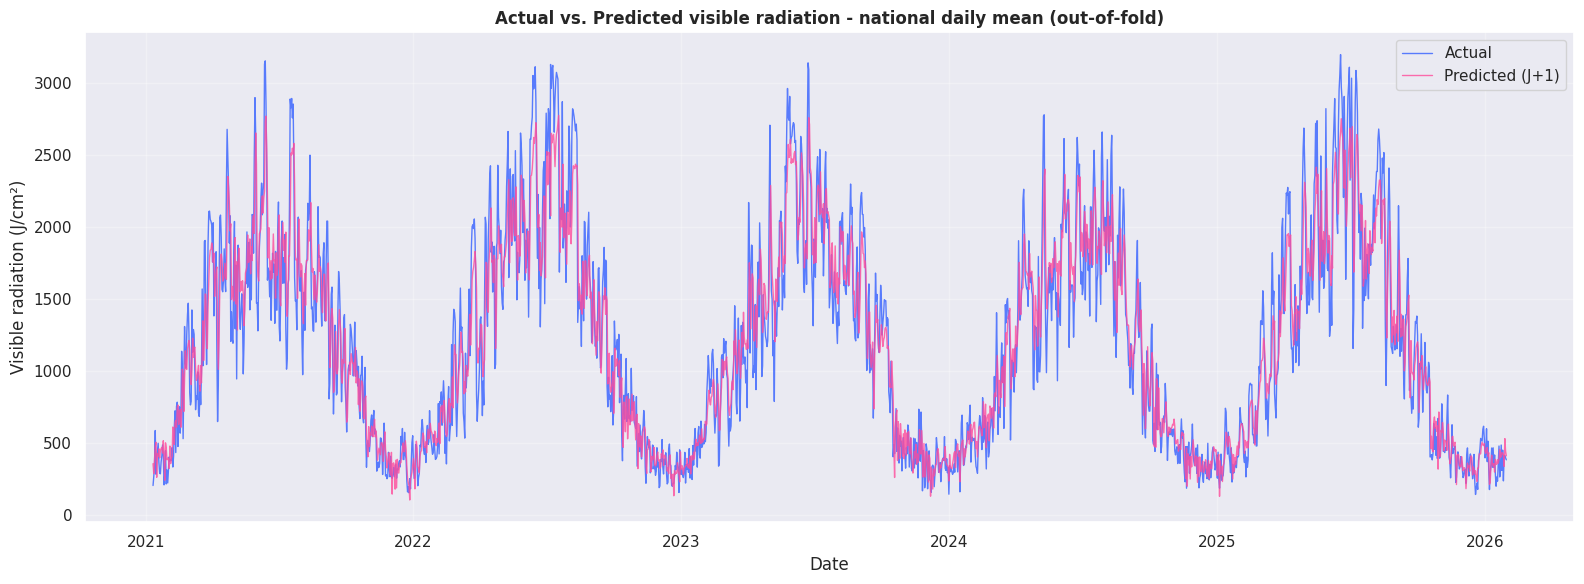

In [223]:
national_daily_pred = (
    fold_predictions_df
    .groupby("date")[["actual", "predicted"]]
    .mean()
    .reset_index()
    .sort_values("date")
)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(national_daily_pred["date"], national_daily_pred["actual"],
        color=ACCENT_BLUE, label="Actual", linewidth=1, alpha=0.8)
ax.plot(national_daily_pred["date"], national_daily_pred["predicted"],
        color=ACCENT_RED, label="Predicted (J+1)", linewidth=1, alpha=0.8)

ax.set_title("Actual vs. Predicted visible radiation - national daily mean (out-of-fold)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Visible radiation (J/cm²)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### &nbsp;&nbsp;&nbsp; 2 - Actual vs. Predicted scatter

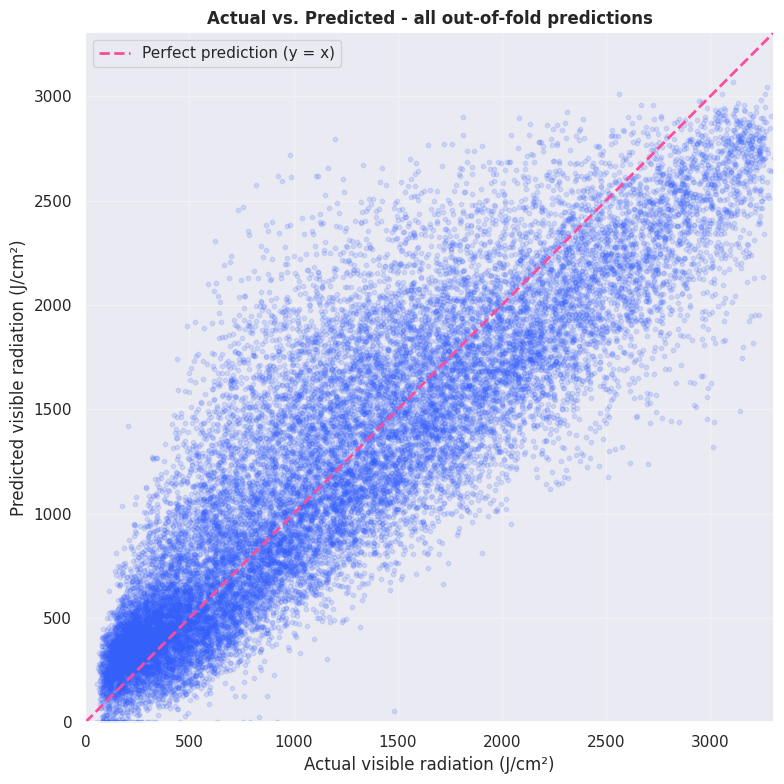

In [224]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(fold_predictions_df["actual"], fold_predictions_df["predicted"],
           alpha=0.15, s=10, color=ACCENT_BLUE)

lims = [
    min(fold_predictions_df["actual"].min(), fold_predictions_df["predicted"].min()),
    max(fold_predictions_df["actual"].max(), fold_predictions_df["predicted"].max())
]
ax.plot(lims, lims, color=ACCENT_RED, linestyle="--", linewidth=2, label="Perfect prediction (y = x)")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual visible radiation (J/cm²)")
ax.set_ylabel("Predicted visible radiation (J/cm²)")
ax.set_title("Actual vs. Predicted - all out-of-fold predictions", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### &nbsp;&nbsp;&nbsp; 3 - Residuals over time

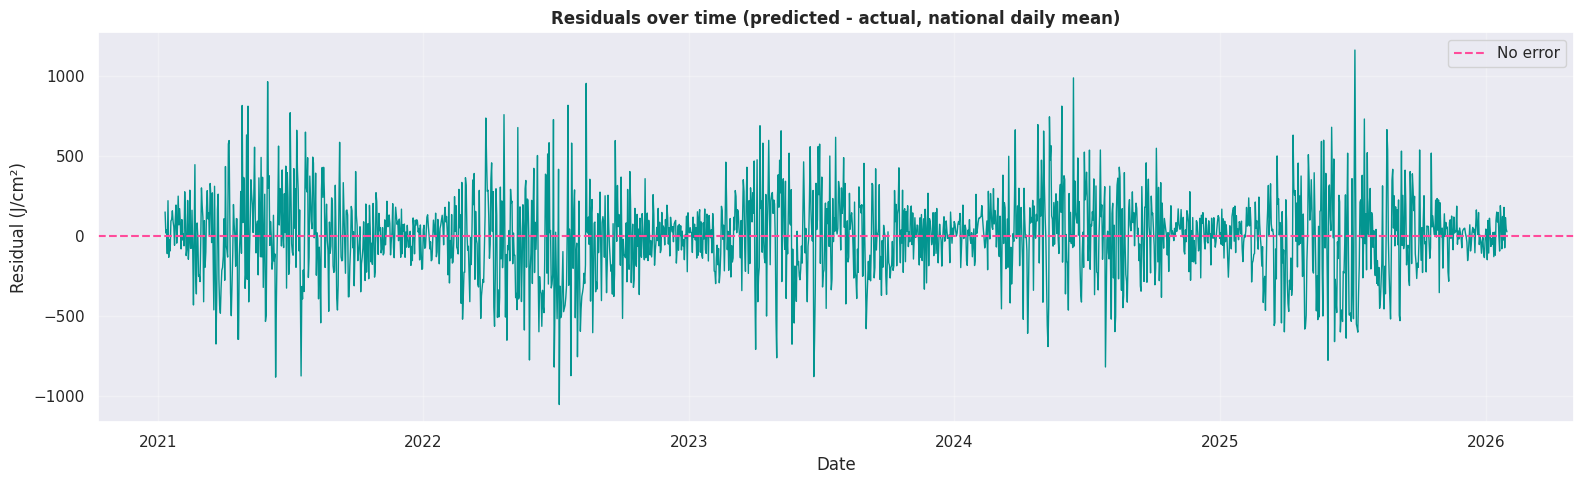

In [225]:
fold_predictions_df["residual"] = fold_predictions_df["predicted"] - fold_predictions_df["actual"]

residuals_daily = (
    fold_predictions_df
    .groupby("date")["residual"]
    .mean()
    .reset_index()
    .sort_values("date")
)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(residuals_daily["date"], residuals_daily["residual"], color=ACCENT_GREEN, linewidth=1)
ax.axhline(0, color=ACCENT_RED, linestyle="--", linewidth=1.5, label="No error")

ax.set_title("Residuals over time (predicted - actual, national daily mean)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Residual (J/cm²)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### &nbsp;&nbsp;&nbsp; 4 - Residual distribution

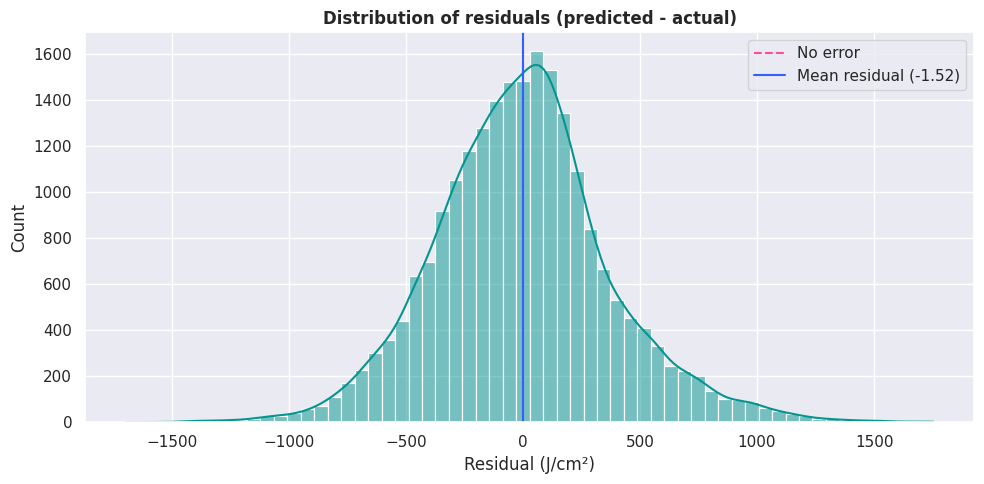

In [226]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(fold_predictions_df["residual"], bins=60, color=ACCENT_GREEN, ax=ax, kde=True)
ax.axvline(0, color=ACCENT_RED, linestyle="--", linewidth=1.5, label="No error")
ax.axvline(fold_predictions_df["residual"].mean(), color=ACCENT_BLUE, linestyle="-", linewidth=1.5,
           label=f"Mean residual ({fold_predictions_df['residual'].mean():.2f})")

ax.set_title("Distribution of residuals (predicted - actual)", fontweight="bold")
ax.set_xlabel("Residual (J/cm²)")
ax.legend()

plt.tight_layout()
plt.show()


### &nbsp;&nbsp;&nbsp; N. Final Dataframe

In [227]:
# =========================
# Prédiction J+1 sur l'ensemble des données, avec le modèle final (Ridge)
# =========================

# Clipped at 0 - see note in section L
ml_df["visible_radiation J+1 predit"] = np.clip(model_ridge.predict(X_full), 0, None)

# =========================
# Écart entre réel et prédit
# =========================

ml_df["radiation_J+1 reel"] = ml_df["target"]

ml_df["ecart prediction"] = (
    ml_df["visible_radiation J+1 predit"]
    - ml_df["radiation_J+1 reel"]
)

# =========================
# Conversion du rayonnement actuel en kWh/m²
# =========================

ml_df["Kwh/m2"] = ml_df["visible_radiation"] / 360

# =========================
# Production solaire actuelle estimée
# Hypothèse : rendement panneau = 20 %
# =========================

ml_df["production_solaire/m2(en Kwh)"] = (
    ml_df["Kwh/m2"] * 0.20
)

# =========================
# Conversion de la prédiction J+1
# =========================

ml_df["Kwh/m2 prédit J+1"] = (
    ml_df["visible_radiation J+1 predit"] / 360
)

ml_df["production_solaire/m2(en Kwh) J+1 predit"] = (
    ml_df["Kwh/m2 prédit J+1"] * 0.20
)

# =========================
# Vérification des dernières lignes
# =========================

display(ml_df.tail())

,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,...,day_sin,day_cos,target,visible_radiation J+1 predit,radiation_J+1 reel,ecart prediction,Kwh/m2,production_solaire/m2(en Kwh),Kwh/m2 prédit J+1,production_solaire/m2(en Kwh) J+1 predit
26575,2026-01-30,Nouvelle-Aquitaine,0.274674,7.625615,9.050724,4.202894,6.103861,2734.351230,519.537120,84.330970,...,0.493776,0.869589,373.240159,402.620229,373.240159,29.380070,1.443159,0.288632,1.118390,0.223678
26576,2026-01-30,Occitanie,1.133113,5.348841,7.107285,2.978725,5.183992,2589.498675,792.694702,78.539901,...,0.493776,0.869589,474.453394,626.651791,474.453394,152.198397,2.201930,0.440386,1.740699,0.348140
26577,2026-01-30,Pays de la Loire,0.000000,5.115501,8.558601,4.251985,6.234064,2884.721739,350.328166,90.125898,...,0.493776,0.869589,426.565974,362.552249,426.565974,-64.013725,0.973134,0.194627,1.007090,0.201418
26578,2026-01-30,Provence-Alpes-Côte d'Azur,0.290364,0.845636,3.241273,1.886909,4.357436,2453.019273,718.443455,81.078000,...,0.493776,0.869589,395.816909,648.812858,395.816909,252.995949,1.995676,0.399135,1.802258,0.360452
26579,2026-01-30,Île-de-France,0.000000,2.786170,7.261170,3.540957,5.743005,2811.523936,299.994681,90.363298,...,0.493776,0.869589,207.585638,326.689452,207.585638,119.103813,0.833319,0.166664,0.907471,0.181494


### &nbsp;&nbsp;&nbsp; O. Data export

In [228]:
ml_df.to_csv(
    r'data/solar_prod_predictions.csv',
    index=False
)